In [2]:
# warning off
import warnings

warnings.filterwarnings("ignore")

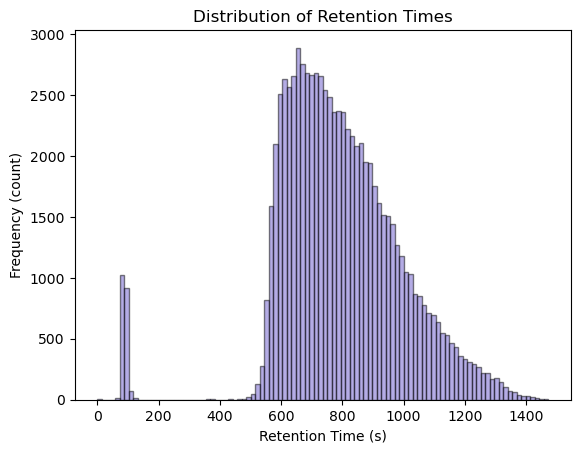

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("/data/home/hadi/RT-TR/data/SMRT_dataset.csv", sep=";")
plt.hist(
    df["rt"],
    bins=100,
    color="slateblue",
    alpha=0.5,
    label="Original",
    edgecolor="black",
)
plt.title("Distribution of Retention Times")
plt.xlabel("Retention Time (s)")
plt.ylabel("Frequency (count)")
plt.savefig("/data/home/hadi/RT-TR/figures/RT_distribution.png", dpi=300)

Number of rows with rt values less than 300 seconds:  2058
 number of molecules is ,77980


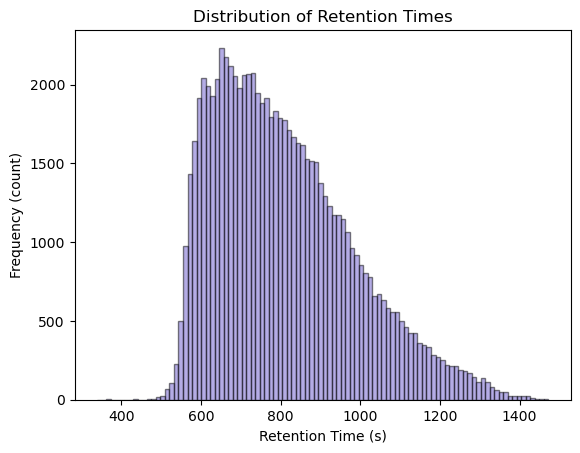

In [4]:
n = 5 * 60  # 5 minutes

df_new = df[df["rt"] > n].reset_index(drop=True)
count = df[df["rt"] < n].count()

print("Number of rows with rt values less than 300 seconds: ", count.iloc[0])
df_new["rt"].describe().round(2)

df = pd.read_csv("/data/home/hadi/RT-TR/data/SMRT_dataset.txt", sep="\t")
plt.title("Distribution of Retention Times")
plt.hist(
    df_new["rt"],
    bins=100,
    color="slateblue",
    alpha=0.5,
    label="Original",
    edgecolor="black",
)
plt.xlabel("Retention Time (s)")
plt.ylabel("Frequency (count)")

print(
    f" number of molecules is ,{df_new['rt'].count()}",
)
plt.savefig("/data/home/hadi/RT-TR/figures/RT_distribution_cut.png", dpi=300)

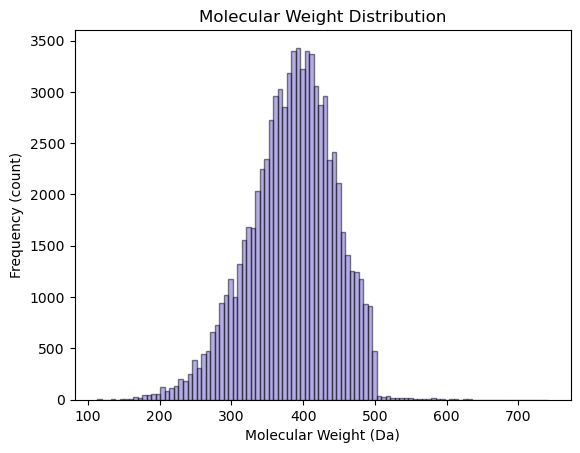

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

# Assuming your DataFrame is named 'df' and the InChI column is named 'inchi'
# Convert InChI to RDKit Mol objects
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)

# Filter out invalid molecules
df = df[df["mol"].notna()]

# Calculate molecular weights
df["mol_weight"] = df["mol"].apply(Descriptors.MolWt)

# Plot the weight distribution
plt.hist(
    df["mol_weight"],
    bins=100,
    color="slateblue",
    alpha=0.5,
    label="Original",
    edgecolor="black",
)
plt.xlabel("Molecular Weight (Da)")
plt.ylabel("Frequency (count)")
plt.title("Molecular Weight Distribution")
plt.savefig("/data/home/hadi/RT-TR/figures/MW_distribution.png", dpi=300)
plt.show()

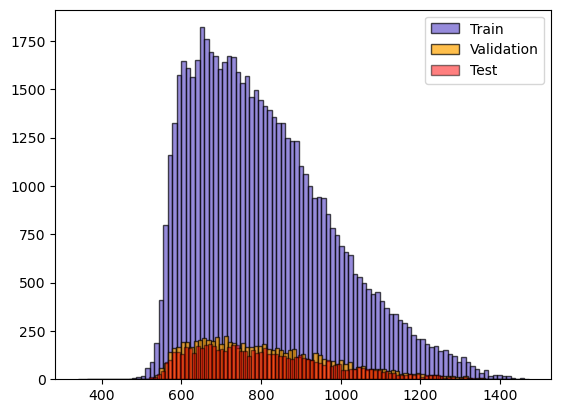

In [6]:
from sklearn.model_selection import train_test_split

# 11, 123, 456, 789
seed = 159
df_train, df_test = train_test_split(df, test_size=0.1, random_state=seed)
df_train, df_val = train_test_split(df_train, test_size=0.1, random_state=seed)

plt.hist(
    df_train["rt"],
    bins=100,
    color="slateblue",
    alpha=0.7,
    label="Train",
    edgecolor="black",
)
plt.hist(
    df_test["rt"],
    bins=100,
    color="orange",
    alpha=0.7,
    label="Validation",
    edgecolor="black",
)
plt.hist(
    df_val["rt"],
    bins=100,
    color="red",
    alpha=0.5,
    label="Test",
    edgecolor="black",
)
plt.legend()

plt.savefig("/data/home/hadi/RT-TR/figures/RT_distribution_split.png", dpi=300)

Estimated Lambdas: [-0.70673732]
Sum of absolute differences between original and rescaled data: 4.25679218096775e-07


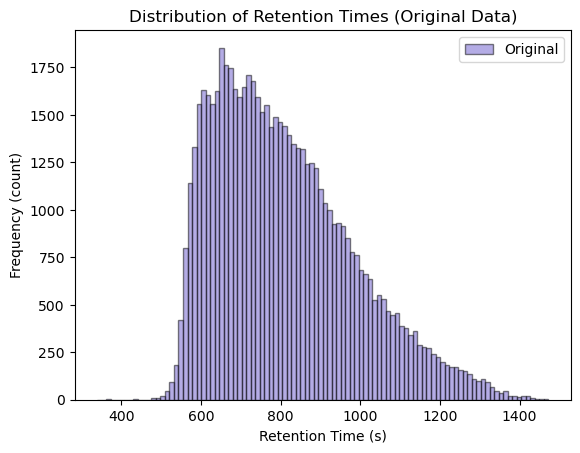

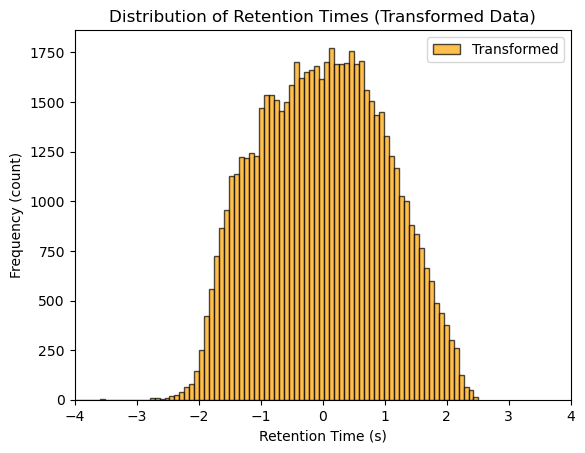

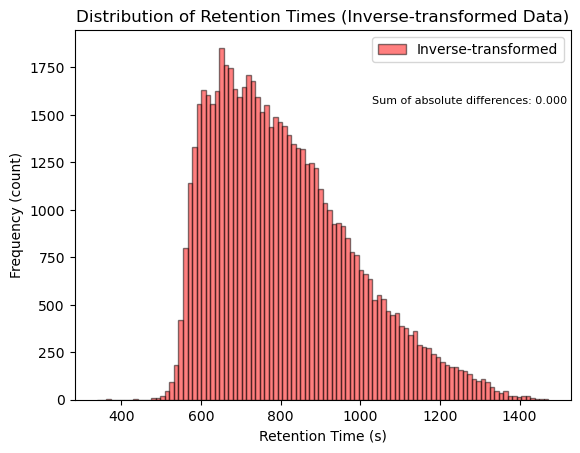

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, StandardScaler

# Set seed for reproducibility
seed = 1

# Load the dataset
data_path = "/data/home/hadi/RT-TR/data/SMRT_dataset.txt"
df = pd.read_csv(data_path, sep="\t")

# Create a binned target variable
df["target_bin"] = pd.cut(df["rt"], bins=10, labels=False)

df_train, df_test = train_test_split(df, test_size=0.1, random_state=seed)
df_train, df_val = train_test_split(df_train, test_size=0.1, random_state=seed)

# Initialize PowerTransformer
scaler = PowerTransformer(method="box-cox", standardize=True)
# scaler= StandardScaler()
# Select numeric columns to transform
numeric_columns = ["rt"]
# Fit and transform the training data
original_data = df_train[numeric_columns]
scaled_data = scaler.fit_transform(df_train[numeric_columns])
rescaled_data = scaler.inverse_transform(scaled_data)

# Retrieve the estimated lambda values
# Note: The optimal λ values for the Box-Cox transformation were estimated using maximum likelihood estimation (MLE) via scikit-learn's PowerTransformer, with the resulting λ values retrieved from the lambdas_ attribute of the fitted transformer object.
print("Estimated Lambdas:", scaler.lambdas_)
# difference between the original and rescaled data sum
diff = np.sum(np.abs(original_data.values - rescaled_data))
print("Sum of absolute differences between original and rescaled data:", diff)

# Plot the original and rescaled data
plt.hist(original_data, bins=100, color="slateblue", alpha=0.5, label="Original", edgecolor="black")
plt.xlabel("Retention Time (s)")
plt.ylabel("Frequency (count)")
plt.title("Distribution of Retention Times (Original Data)")
plt.legend()
plt.savefig("/data/home/hadi/RT-TR/figures/RT_distribution_original.png", dpi=300)
plt.show()
# now plot the scaled data
plt.hist(scaled_data, bins=100, color="orange", alpha=0.7, label="Transformed", edgecolor="black")
# -4, 4 is the range of the scaled data
plt.xlim(-4, 4)
plt.xlabel("Retention Time (s)")
plt.ylabel("Frequency (count)")
plt.title("Distribution of Retention Times (Transformed Data)")
plt.legend()
plt.savefig("/data/home/hadi/RT-TR/figures/RT_distribution_transformed.png", dpi=300)
plt.show()
# Plot the original and rescaled data
plt.hist(rescaled_data, bins=100, color="red", alpha=0.5, label="Inverse-transformed", edgecolor="black")
plt.xlabel("Retention Time (s)")
plt.ylabel("Frequency (count)")
plt.title("Distribution of Retention Times (Inverse-transformed Data)")
plt.text(0.6, 0.8, f"Sum of absolute differences: {diff:.3f}", transform=plt.gca().transAxes, fontsize=8)
plt.legend()
plt.savefig("/data/home/hadi/RT-TR/figures/RT_distribution_transformed.png", dpi=300)
plt.show()

Cao_HILIC_116 dataset:  Max RT: 958.20 sec | Min RT: 63.60 sec
Eawag_XBridgeC18_364 dataset:  Max RT: 1224.00 sec | Min RT: 48.00 sec
FEM_lipids_72 dataset:  Max RT: 1494.00 sec | Min RT: 72.00 sec
FEM_long_412 dataset:  Max RT: 3672.00 sec | Min RT: 41.40 sec
FEM_short_73 dataset:  Max RT: 1317.60 sec | Min RT: 74.55 sec
IPB_Halle_82 dataset:  Max RT: 719.80 sec | Min RT: 24.44 sec
LIFE_new_184 dataset:  Max RT: 330.87 sec | Min RT: 24.21 sec
LIFE_old_194 dataset:  Max RT: 336.99 sec | Min RT: 30.59 sec
MTBLS87_147 dataset:  Max RT: 1488.00 sec | Min RT: 228.00 sec
UniToyama_Atlantis_143 dataset:  Max RT: 1920.80 sec | Min RT: 221.60 sec


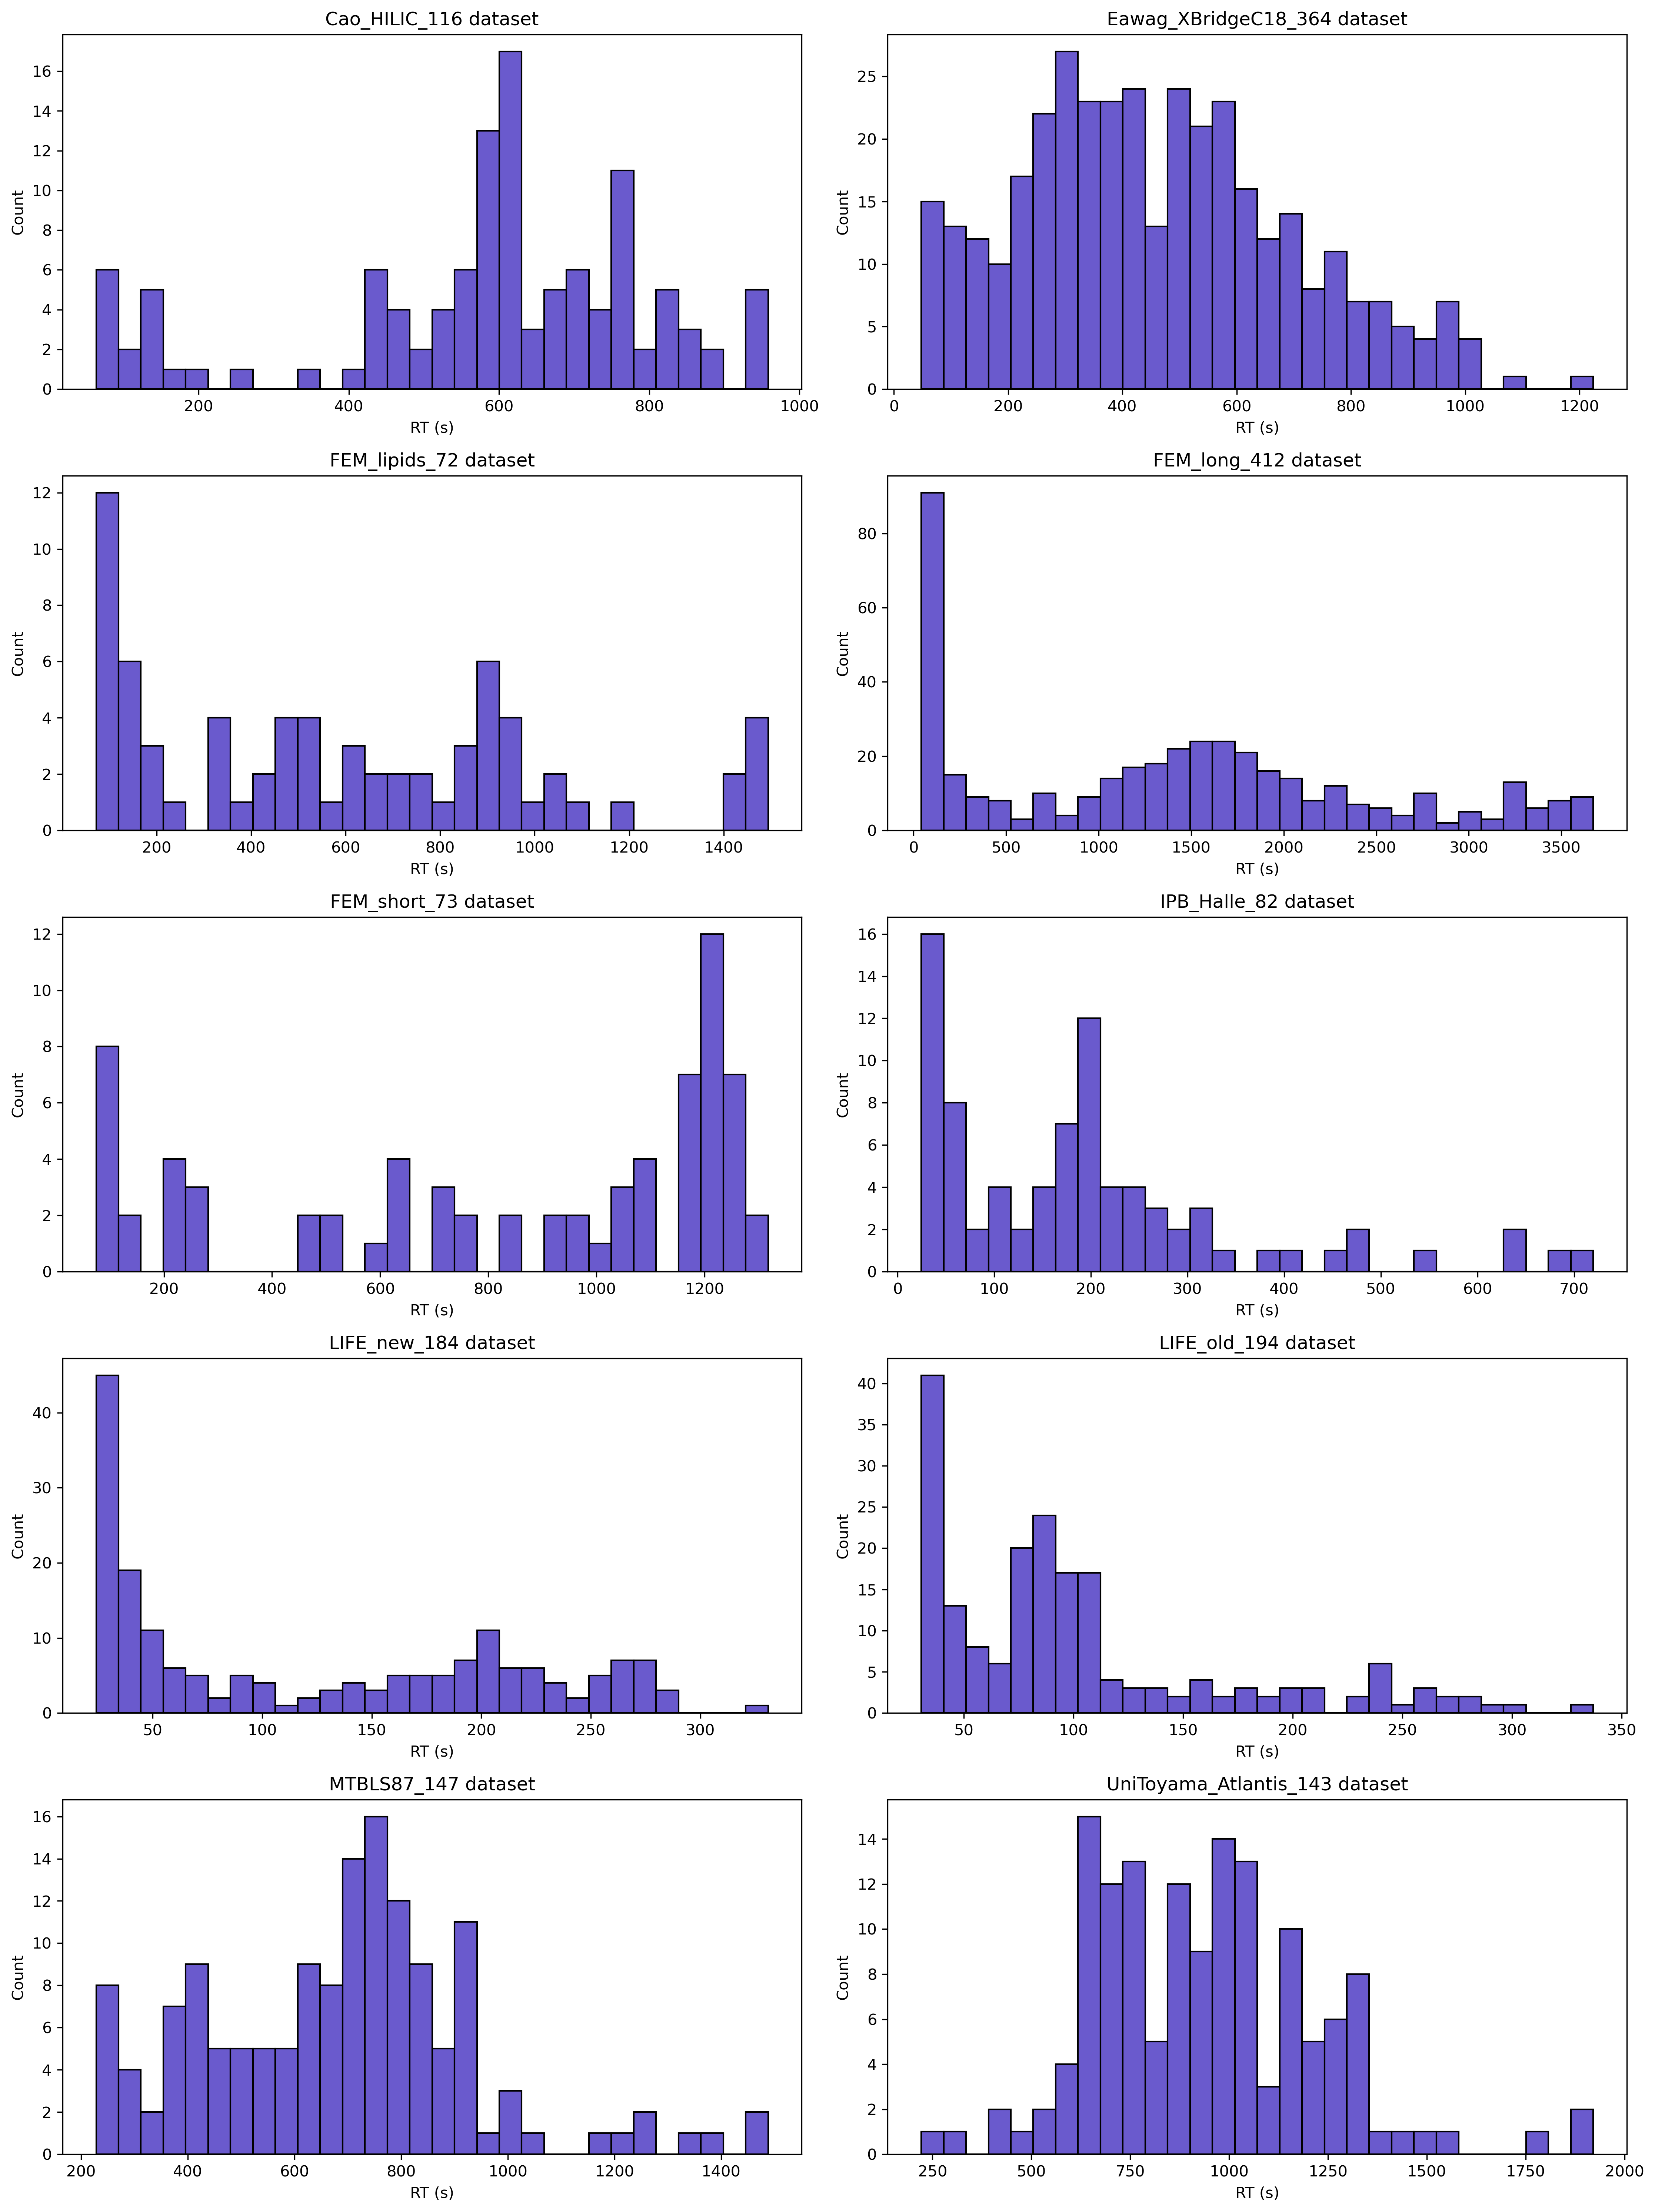

In [8]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

# histogram of rts
paths = glob.glob("/data/home/hadi/RT-TR/data/dataset/10_subdataset_smiles/*.txt")

num_datasets = len(paths)
names = [path.split("/")[-1].split(".")[0] for path in paths]

dfs = [pd.read_csv(path, sep="\t") for path in paths]

# plot with legend separate for each dataset as a subplot in 2 columns
fig, axs = plt.subplots(num_datasets // 2, 2, figsize=(15, 20), dpi=300)
axs = axs.ravel()
for i, (df, name) in enumerate(zip(dfs, names)):
    df["rt"].hist(bins=30, ax=axs[i], color="slateblue", edgecolor="black")
    axs[i].set_title(f"{name} dataset")
    axs[i].set_xlabel("RT (s)")
    axs[i].set_ylabel("Count")
    axs[i].grid(False)
    # print max and min value
    print(f"{name} dataset:  Max RT: {df['rt'].max():.2f} sec | Min RT: {df['rt'].min():.2f} sec")
plt.tight_layout()
plt.savefig("/data/home/hadi/RT-TR/figures/RT_distribution_subdatasets.png", dpi=300)
plt.show()

# Plotting Results

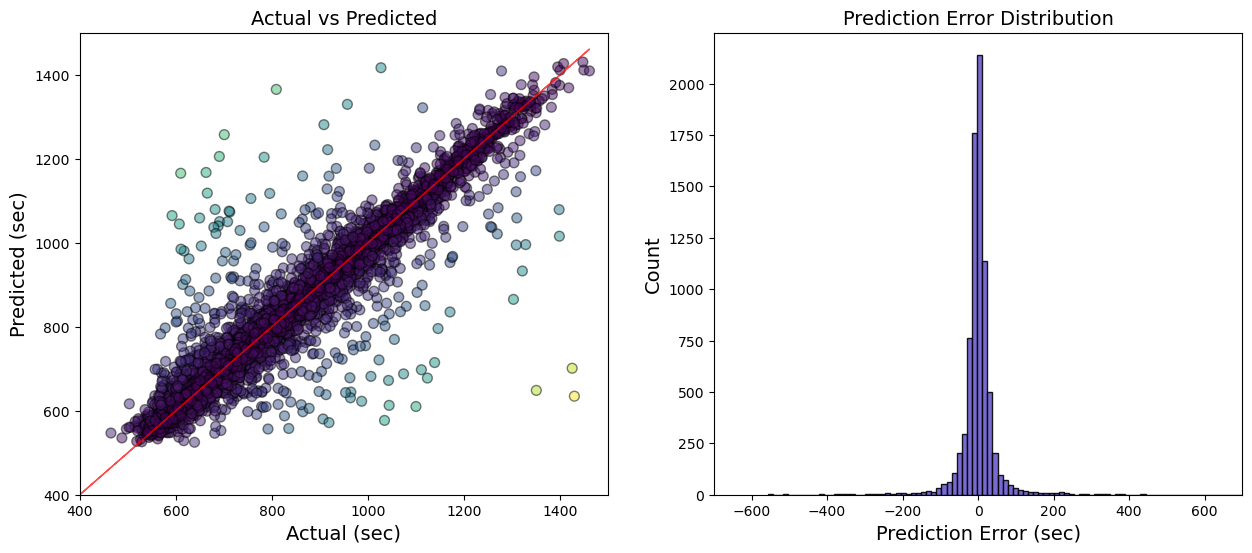

In [9]:
import sys

sys.path.append("/data/home/hadi/test")

import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import numpy as np
from helper import process_predictions
import seaborn as sns

result = pd.read_csv("../resullt_predict/results_test_set.csv")

# Calculate the distance of each point from the diagonal line
distances = np.abs(result["rt"] - result["prediction"])

# Create a colormap based on the distances
cmap = plt.cm.get_cmap("viridis")
colors = cmap(distances / distances.max())
# plot
fig, axs = plt.subplots(
    1,
    2,
    figsize=(15, 6),
)

# Scatter plot of actual vs predicted
axs[0].plot(result["rt"].values, result["rt"].values, color="red", lw=1, alpha=0.7)
axs[0].scatter(result["rt"], result["prediction"], alpha=0.5, c=colors, edgecolors="k", s=50)
axs[0].set_xlabel("Actual (sec)", fontsize=14)
axs[0].set_ylabel("Predicted (sec)", fontsize=14)
axs[0].set_title("Actual vs Predicted", fontsize=14)
axs[0].set_xlim(400, 1500)
axs[0].set_ylim(400, 1500)
# Error distribution plot
error = result["rt"] - result["prediction"]
axs[1].hist(error, bins=100, edgecolor="black", color="slateblue", alpha=0.9)
axs[1].set_xlabel("Prediction Error (sec)", fontsize=14)
axs[1].set_ylabel("Count", fontsize=14)
axs[1].set_title("Prediction Error Distribution", fontsize=14)
axs[1].set_xlim(-700, 700)

# remove splines use sns
# sns.despine()
plt.savefig("/data/home/hadi/RT-TR/figures/RT_prediction.png", dpi=300)


In [10]:
list_dataset = glob.glob("/data/home/hadi/test/data/dataset/10_subdataset_smiles/*.txt")

# get only name of the files using split
dataset_names = [dataset.split("/")[-1].split(".")[0] for dataset in list_dataset]
dataset_names

['Cao_HILIC_116',
 'Eawag_XBridgeC18_364',
 'FEM_lipids_72',
 'FEM_long_412',
 'FEM_short_73',
 'IPB_Halle_82',
 'LIFE_new_184',
 'LIFE_old_194',
 'MTBLS87_147',
 'UniToyama_Atlantis_143']

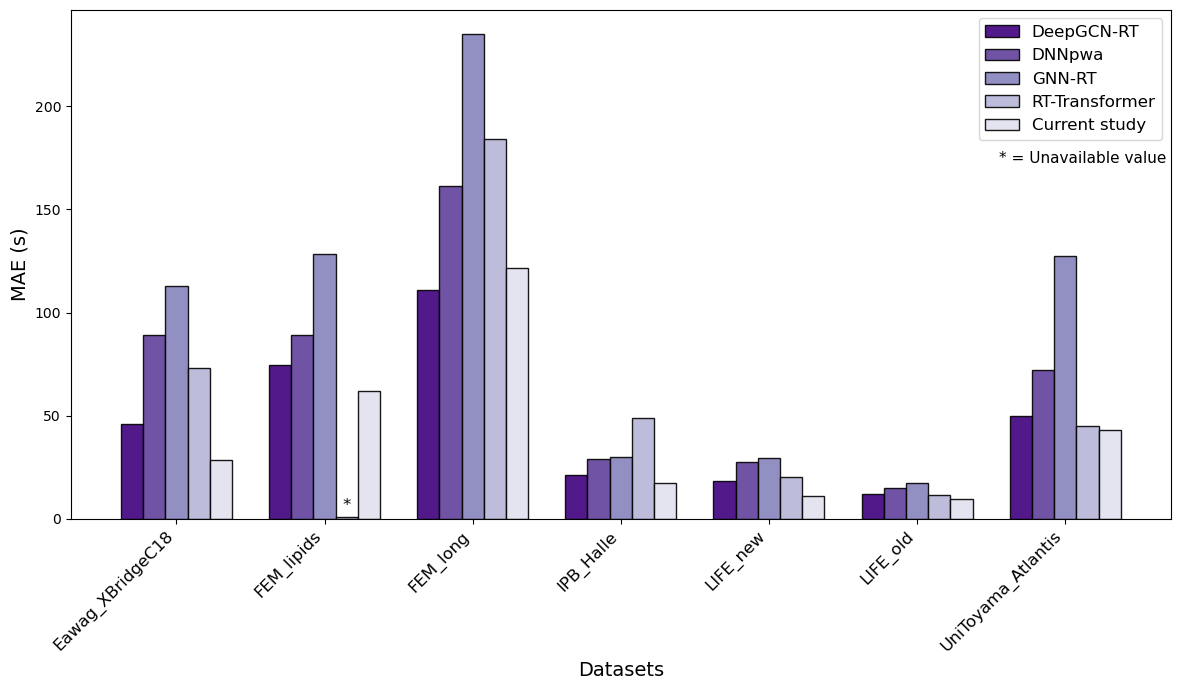

In [11]:
import matplotlib.pyplot as plt
import glob
import numpy as np
import matplotlib.cm as cm
import matplotlib.patches as mpatches  # To add custom legend entries

# Sample data for the plot
# Dataset: UFZ_Phenomenex, RIKEN, Cao_HILIC, MTBLS87_147, FEM_short

categories = [
    "Eawag_XBridgeC18",
    "FEM_lipids",
    "FEM_long",
    "IPB_Halle",
    "LIFE_new",
    "LIFE_old",
    "UniToyama_Atlantis",
]
values_gnn_rt = [112.78, 128.25, 235.01, 29.76, 29.38, 17.10, 127.52]
values_dnnpwa = [89.26, 89.32, 161.58, 28.85, 27.53, 15.11, 72.3]
values_deepgcn = [45.97, 74.48, 110.89, 21.20, 18.13, 12.07, 50.03]
values_RT_trans = [73.34, 1.00, 184.04, 48.75, 20.36, 11.57, 44.8]
values_current = [28.59, 62.07, 121.70, 17.37, 10.91, 09.68, 43.16]

## Has a value 1.00 (marked as unavailable)

# Position of bars on the x-axis
x = np.arange(len(categories))
colors = cm.get_cmap("Purples_r", 6)  # Use colormap with 5 distinct colors
colors = [colors(i) for i in range(5)]
# colors = [colors(0.4), colors(0.5), colors(0.8)]  # Extract the colors
# colors = ['#a6cee3', '#1f78b4', '#084c6f']

# Width of the bars
width = 0.15

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plotting the bars for 5 models
bars1 = ax.bar(x - 2 * width, values_deepgcn, width, label="DeepGCN-RT", color=colors[0], edgecolor="black", alpha=0.9)
bars2 = ax.bar(x - width, values_dnnpwa, width, label="DNNpwa", color=colors[1], edgecolor="black", alpha=0.9)
bars3 = ax.bar(x, values_gnn_rt, width, label="GNN-RT", color=colors[2], edgecolor="black", alpha=0.9)
bars4 = ax.bar(x + width, values_RT_trans, width, label="RT-Transformer", color=colors[3], edgecolor="black", alpha=0.9)
bars5 = ax.bar(
    x + 2 * width, values_current, width, label="Current study", color=colors[4], edgecolor="black", alpha=0.9
)

for i, value in enumerate(values_RT_trans):
    if value == 1.00:
        ax.text(x[i] + 0.15, value + 2, "*", ha="center", va="bottom", fontsize=12, color="k")

# Set the title and labels
ax.set_xlabel("Datasets", fontsize=14)
ax.set_ylabel("MAE (s)", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right", fontsize=12)
# put text below the legend
ax.text(0.92, 0.70, "* = Unavailable value", transform=ax.transAxes, ha="center", fontsize=11)

# Add the custom legend entry for *
ax.legend(loc="upper right", fontsize=12, frameon=True)

# Display the plot
plt.tight_layout()
plt.savefig("/data/home/hadi/RT-TR/figures/MAE_comparison.png", dpi=300)
plt.show()


# Metrics for conisderation of ranking of the predictions

In [13]:
import pandas as pd
from scipy.stats import kendalltau, spearmanr

data = pd.read_csv("/data/home/hadi/RT-TR/notebooks/resullt_predict/results_test_set.csv")
# Calculate Spearman's rank correlation
spearman_corr, _ = spearmanr(data["prediction"], data["rt"])

print(f"Spearman's Rank Correlation: {spearman_corr:.4f}")

# Calculate Kendall's Tau
kendall_tau, _ = kendalltau(data["prediction"], data["rt"])
print(f"Kendall's Tau: {kendall_tau:.4f}")


Spearman's Rank Correlation: 0.9543
Kendall's Tau: 0.8616


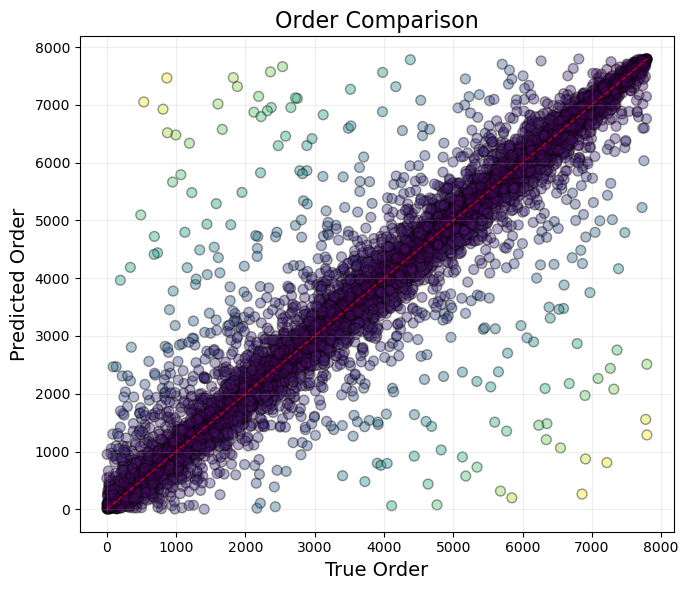

In [14]:
# Calculate the absolute difference between the predicted and true ranks
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Add rank columns
data["pred_rank"] = data["prediction"].rank()
data["rt_rank"] = data["rt"].rank()

# Calculate the distance of each point from the diagonal line
distances = np.abs(data["rt_rank"] - data["pred_rank"])

# Create a colormap based on the distances
cmap = plt.cm.get_cmap("viridis")
colors = cmap(distances / distances.max())

# Plot the ranks
plt.figure(figsize=(7, 6))
plt.scatter(data["rt_rank"], data["pred_rank"], alpha=0.4, c=colors, edgecolors="k", s=50)

# Add the perfect alignment line
plt.plot([1, len(data)], [1, len(data)], color="red", linestyle="--", lw=1, alpha=0.7)

# Add labels, title, and legend
plt.xlabel("True Order", fontsize=14)
plt.ylabel("Predicted Order", fontsize=14)
plt.title("Order Comparison", fontsize=16)

# Add grid for better readability
plt.grid(alpha=0.2)

# Show the plot
plt.tight_layout()
plt.savefig("/data/home/hadi/RT-TR/figures/rank_comparison.png", dpi=300)
plt.show()

In [13]:
# calculate the mean absolute error
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

data = pd.read_csv(
    "/data/home/hadi/RT-TR/data/results_new_model.csv",
)
prediction = data["prediction"]
true = data["rt"]

mae = mean_absolute_error(true, prediction)
mape = mean_absolute_percentage_error(true, prediction)
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Absolute Percentage Error: {mape * 100:.4f} %")


Mean Absolute Error: 26.2352
Mean Absolute Percentage Error: 3.2496 %


# Transfer Learning Resutls

/data/home/hadi/RT-TR/_runs/2024_09_30/08_29_ewag
/data/home/hadi/RT-TR/_runs/2024_09_30/21_24_long
/data/home/hadi/RT-TR/_runs/2024_09_30/21_26_ipb
/data/home/hadi/RT-TR/_runs/2024_09_30/21_26_new
/data/home/hadi/RT-TR/_runs/2024_09_30/21_28_old
/data/home/hadi/RT-TR/_runs/2024_09_30/21_30_atla
/data/home/hadi/RT-TR/_runs/2024_09_30/21_33_MTB
/data/home/hadi/RT-TR/_runs/2024_09_30/21_36_lip
/data/home/hadi/RT-TR/_runs/2024_09_30/21_38_cao
/data/home/hadi/RT-TR/_runs/2024_09_30/21_46_short
/data/home/hadi/RT-TR/_runs/2024_09_30/22_24_riken


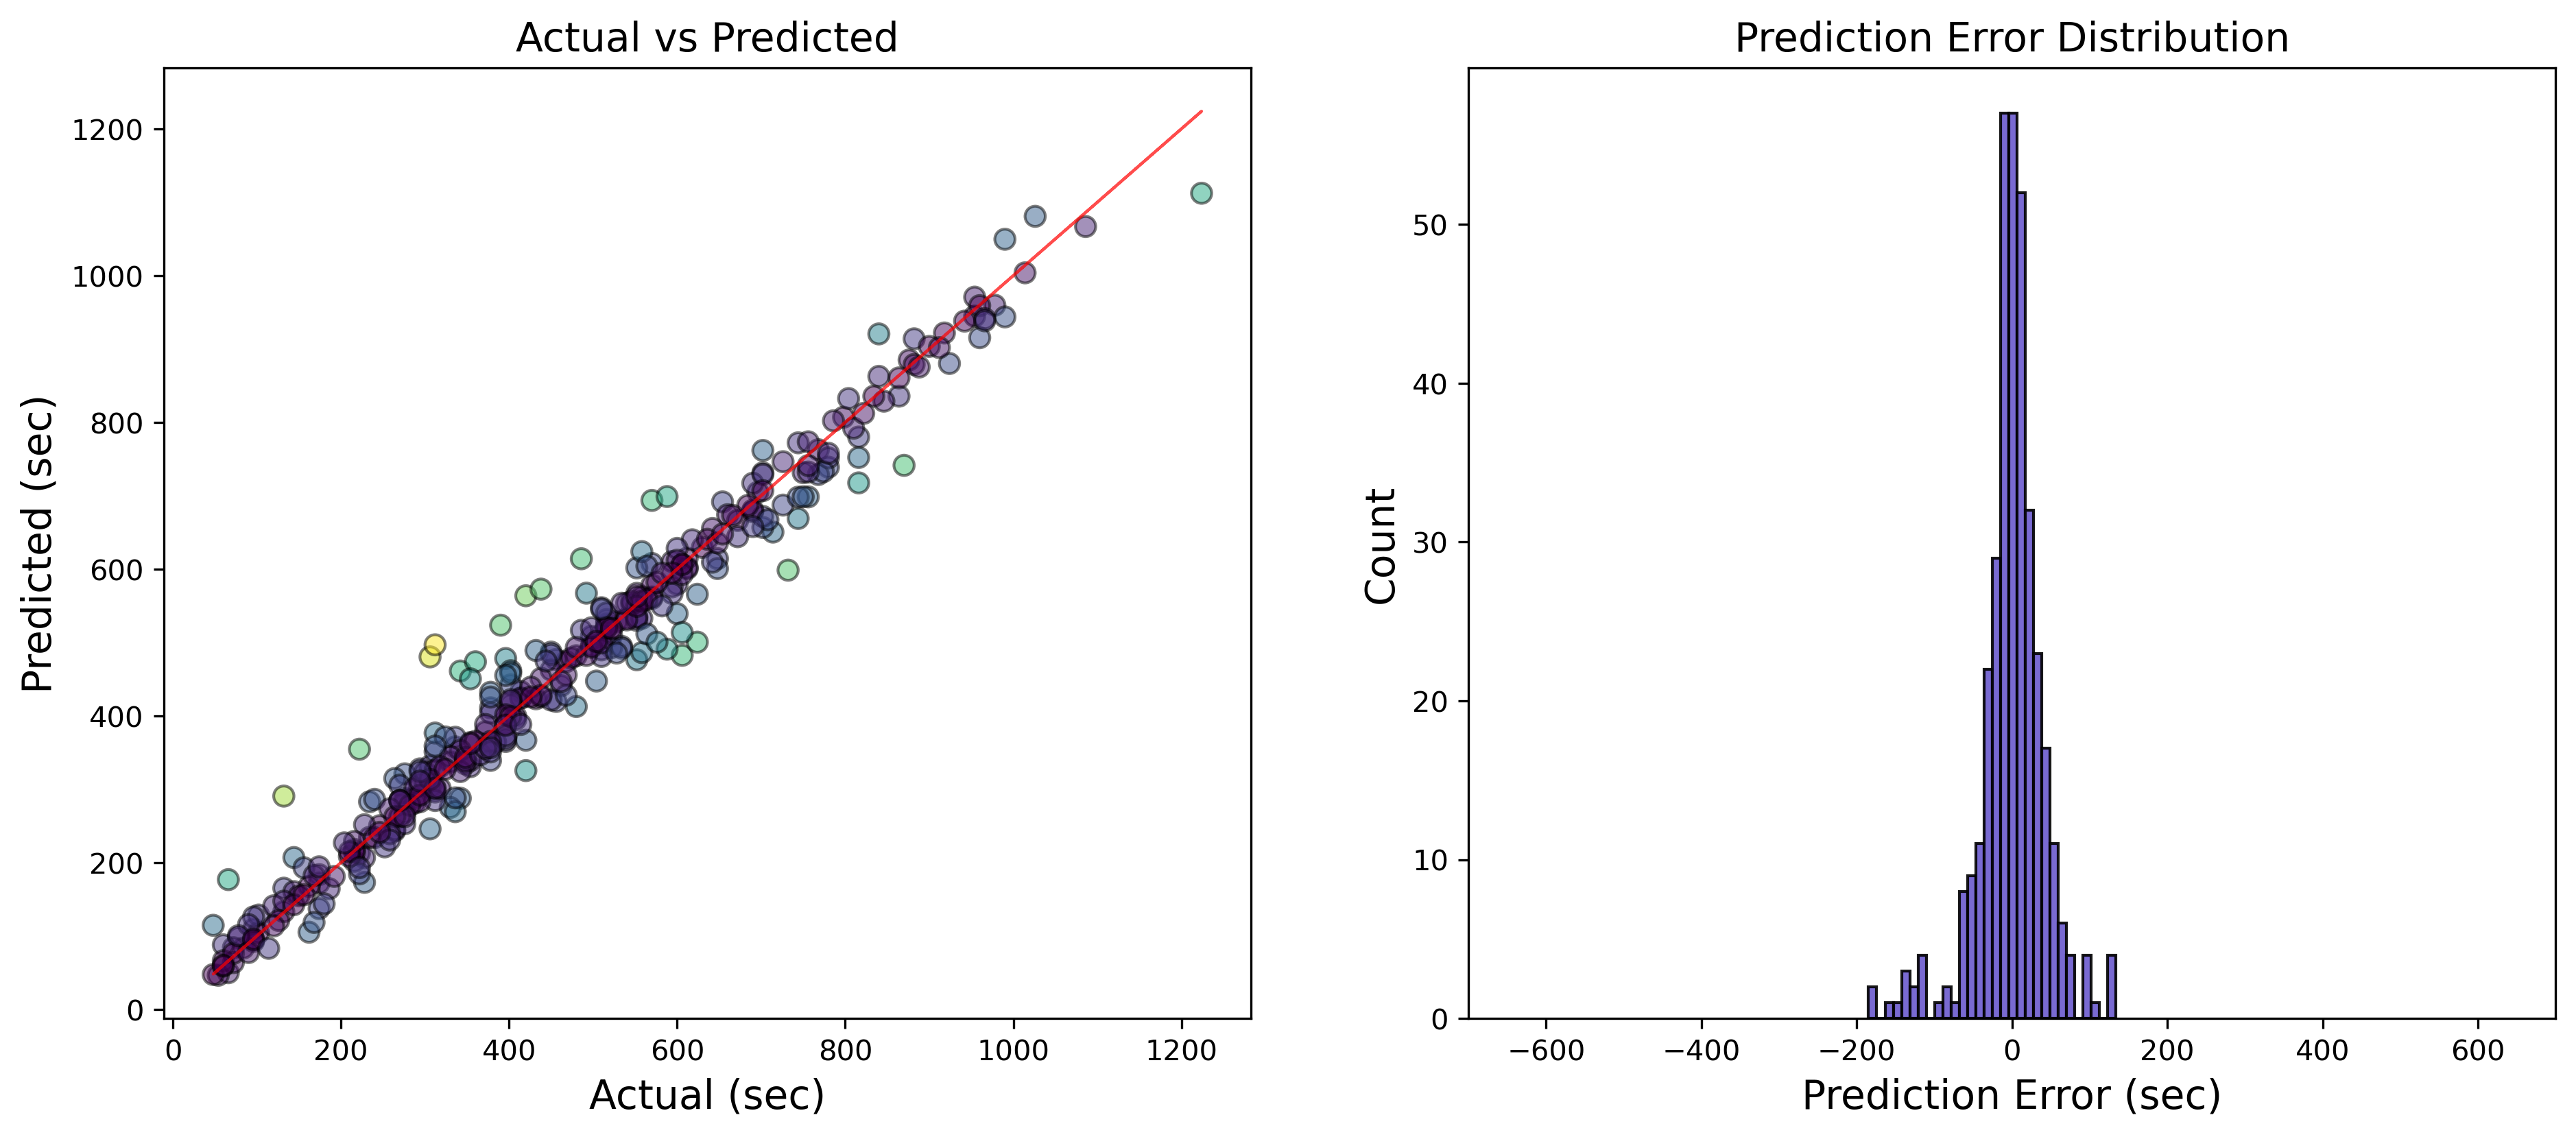

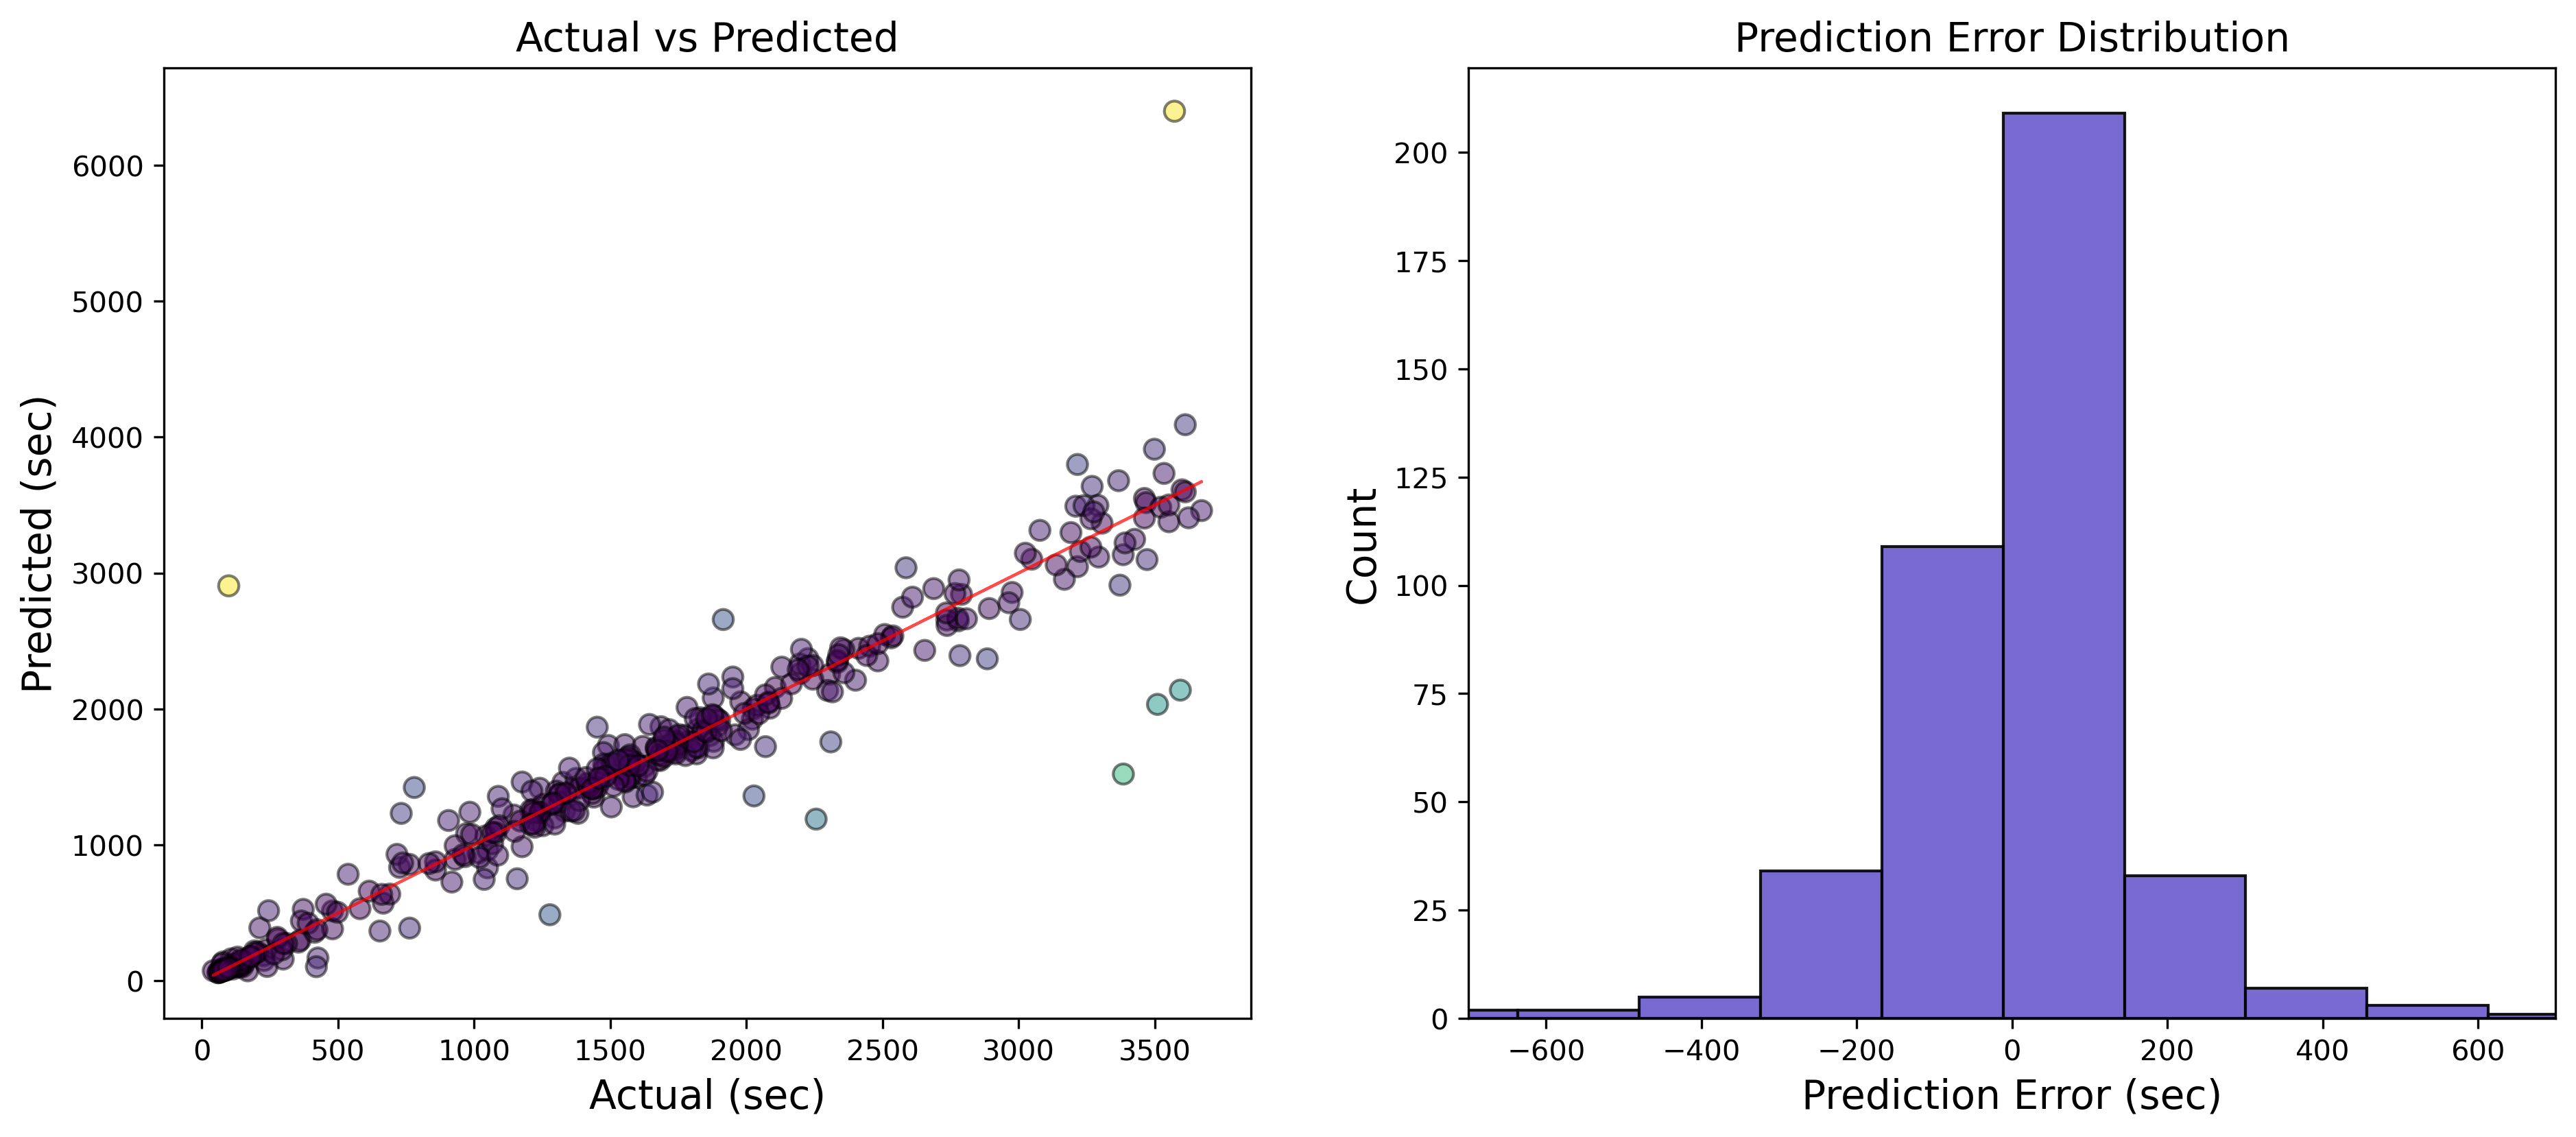

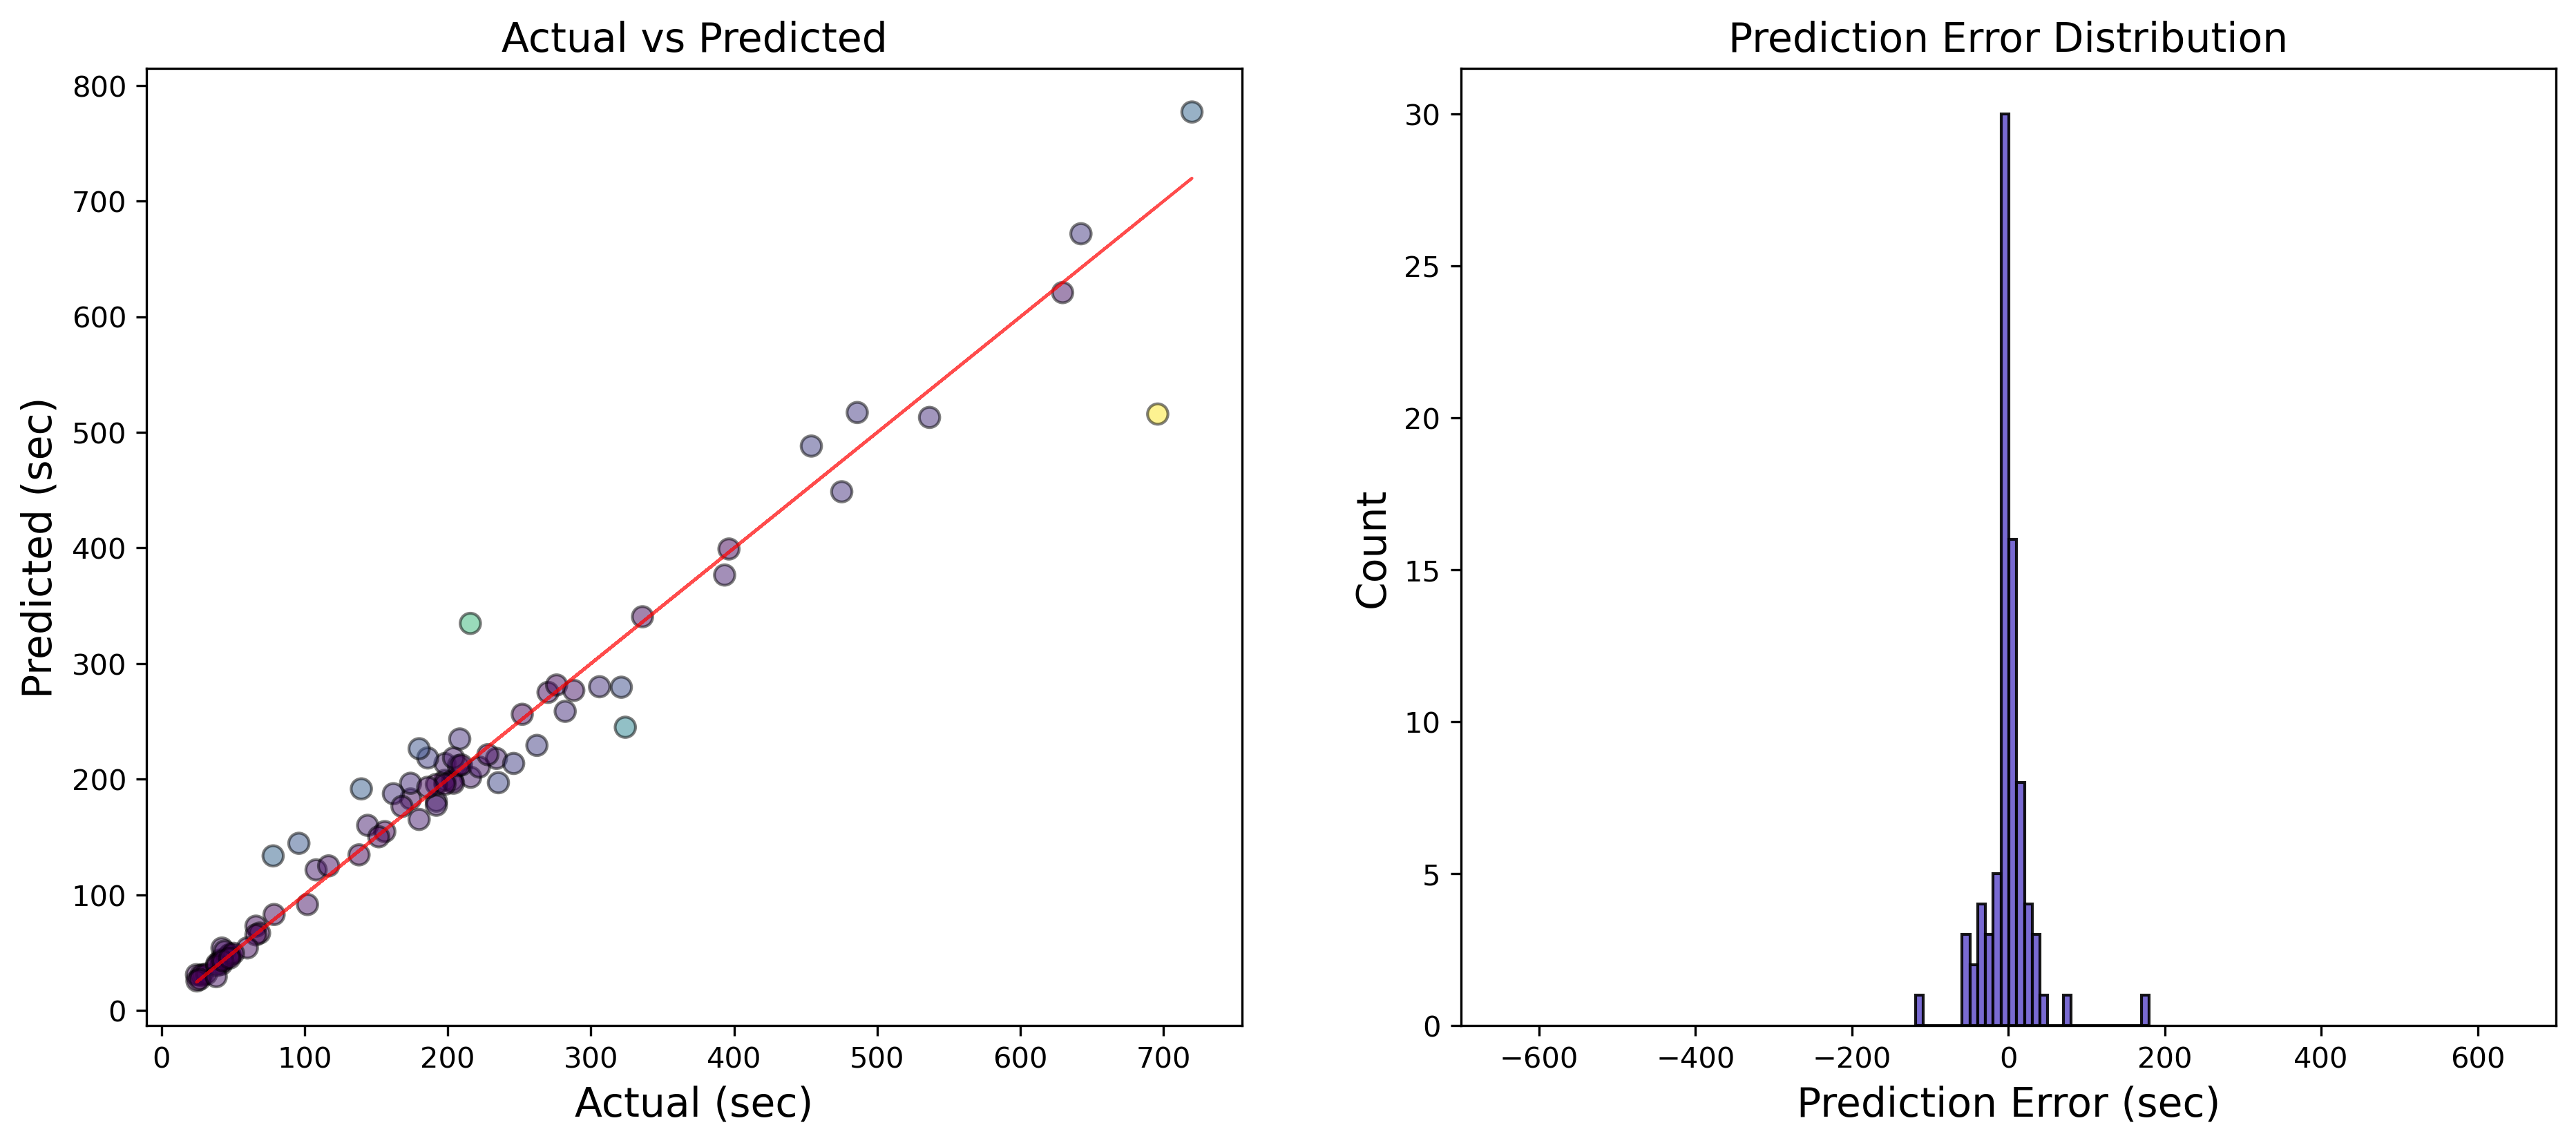

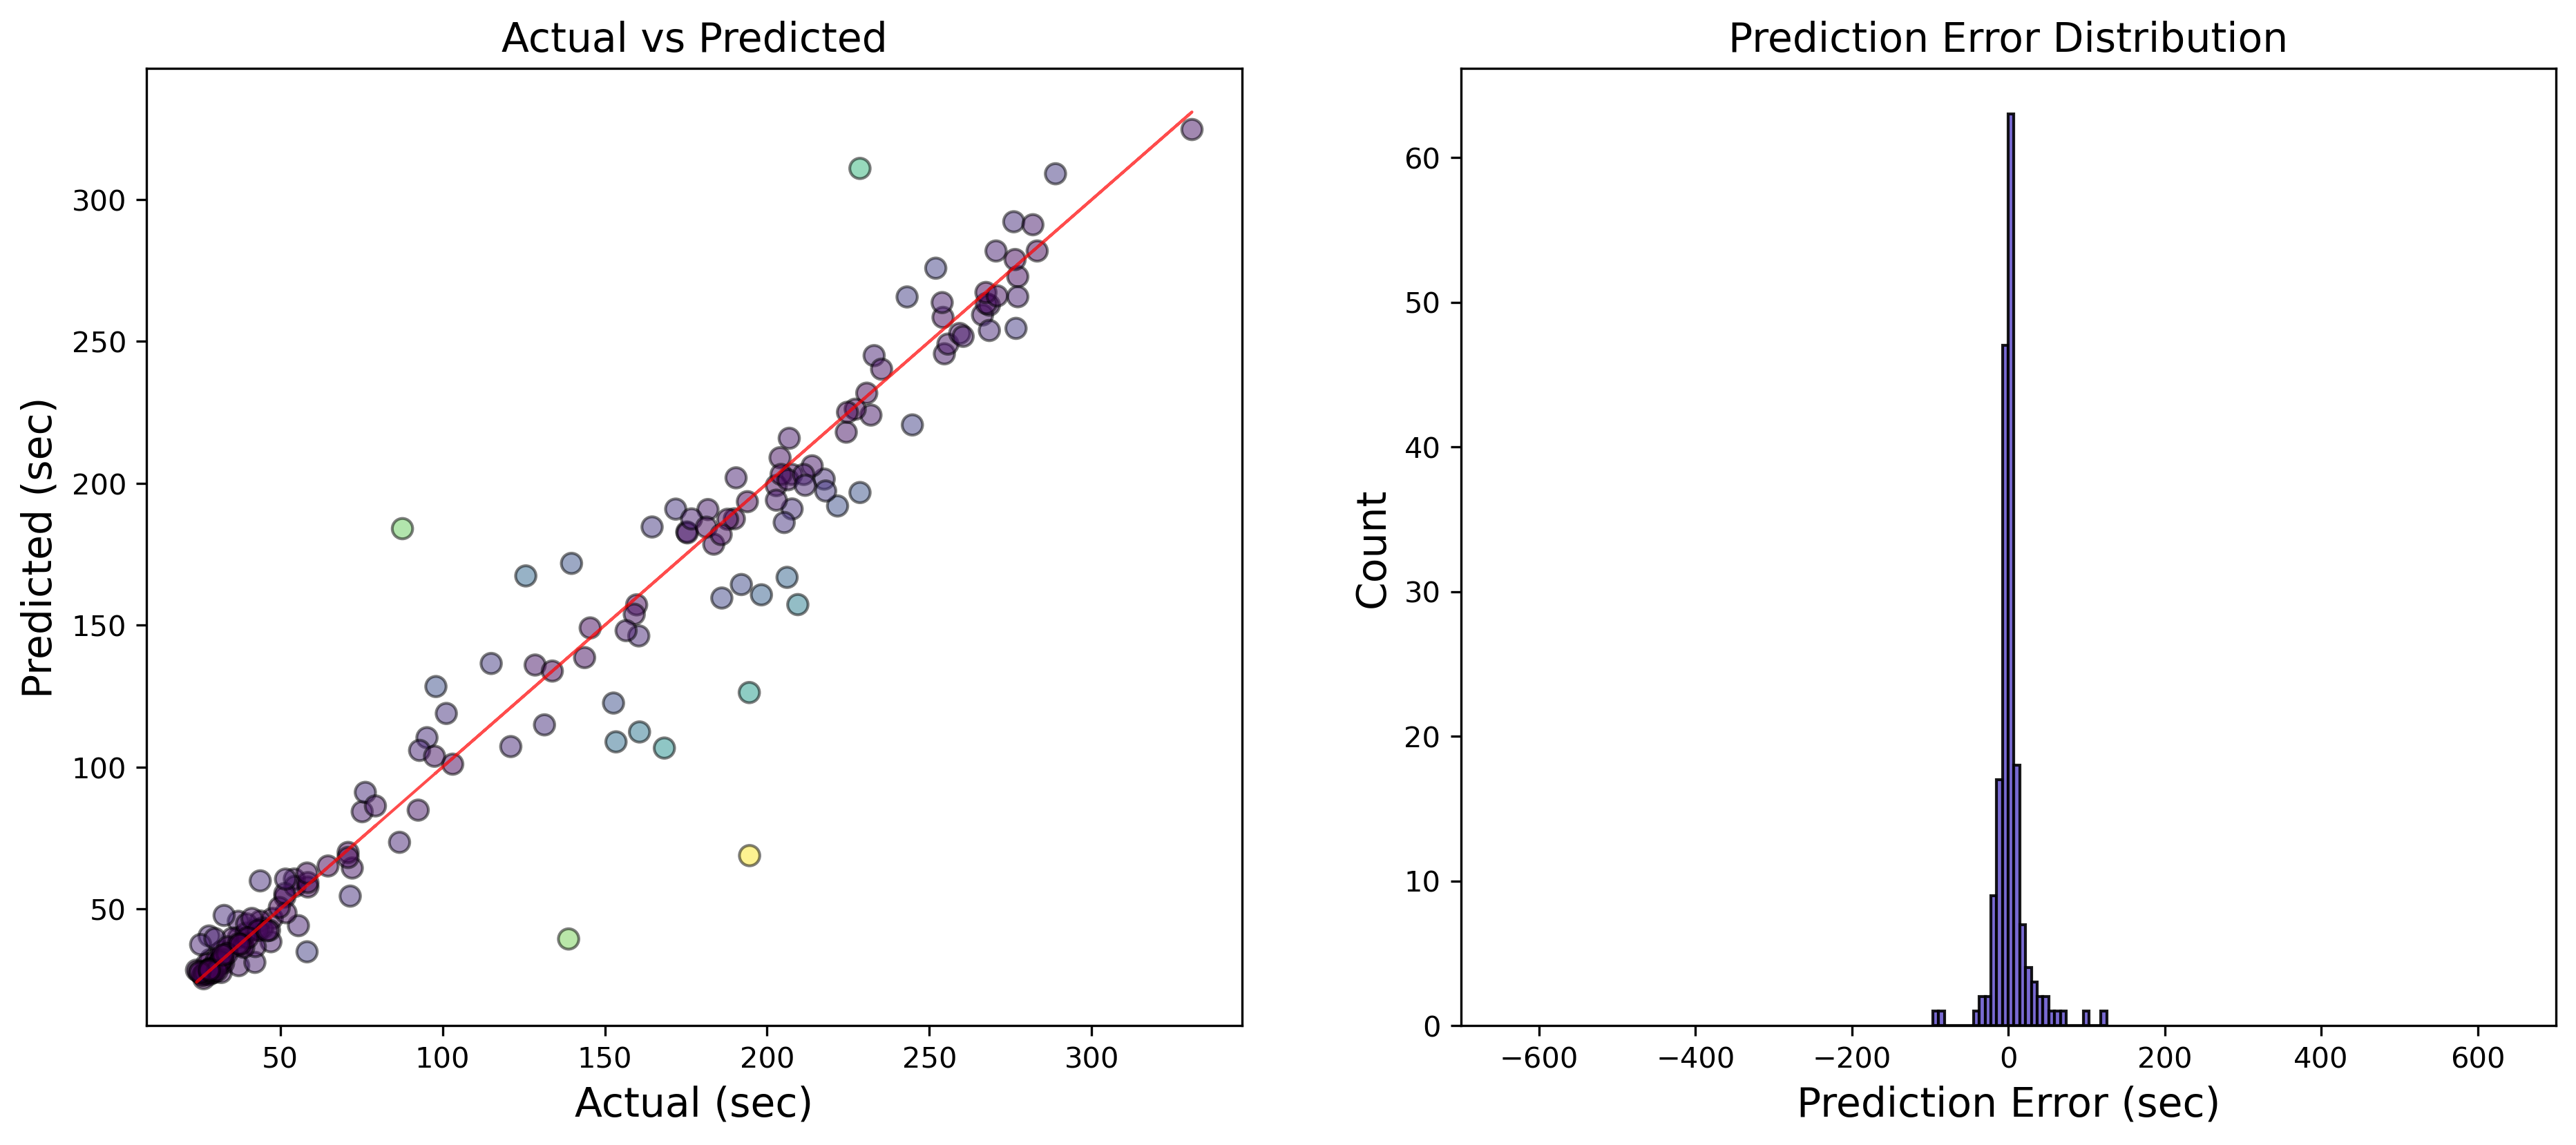

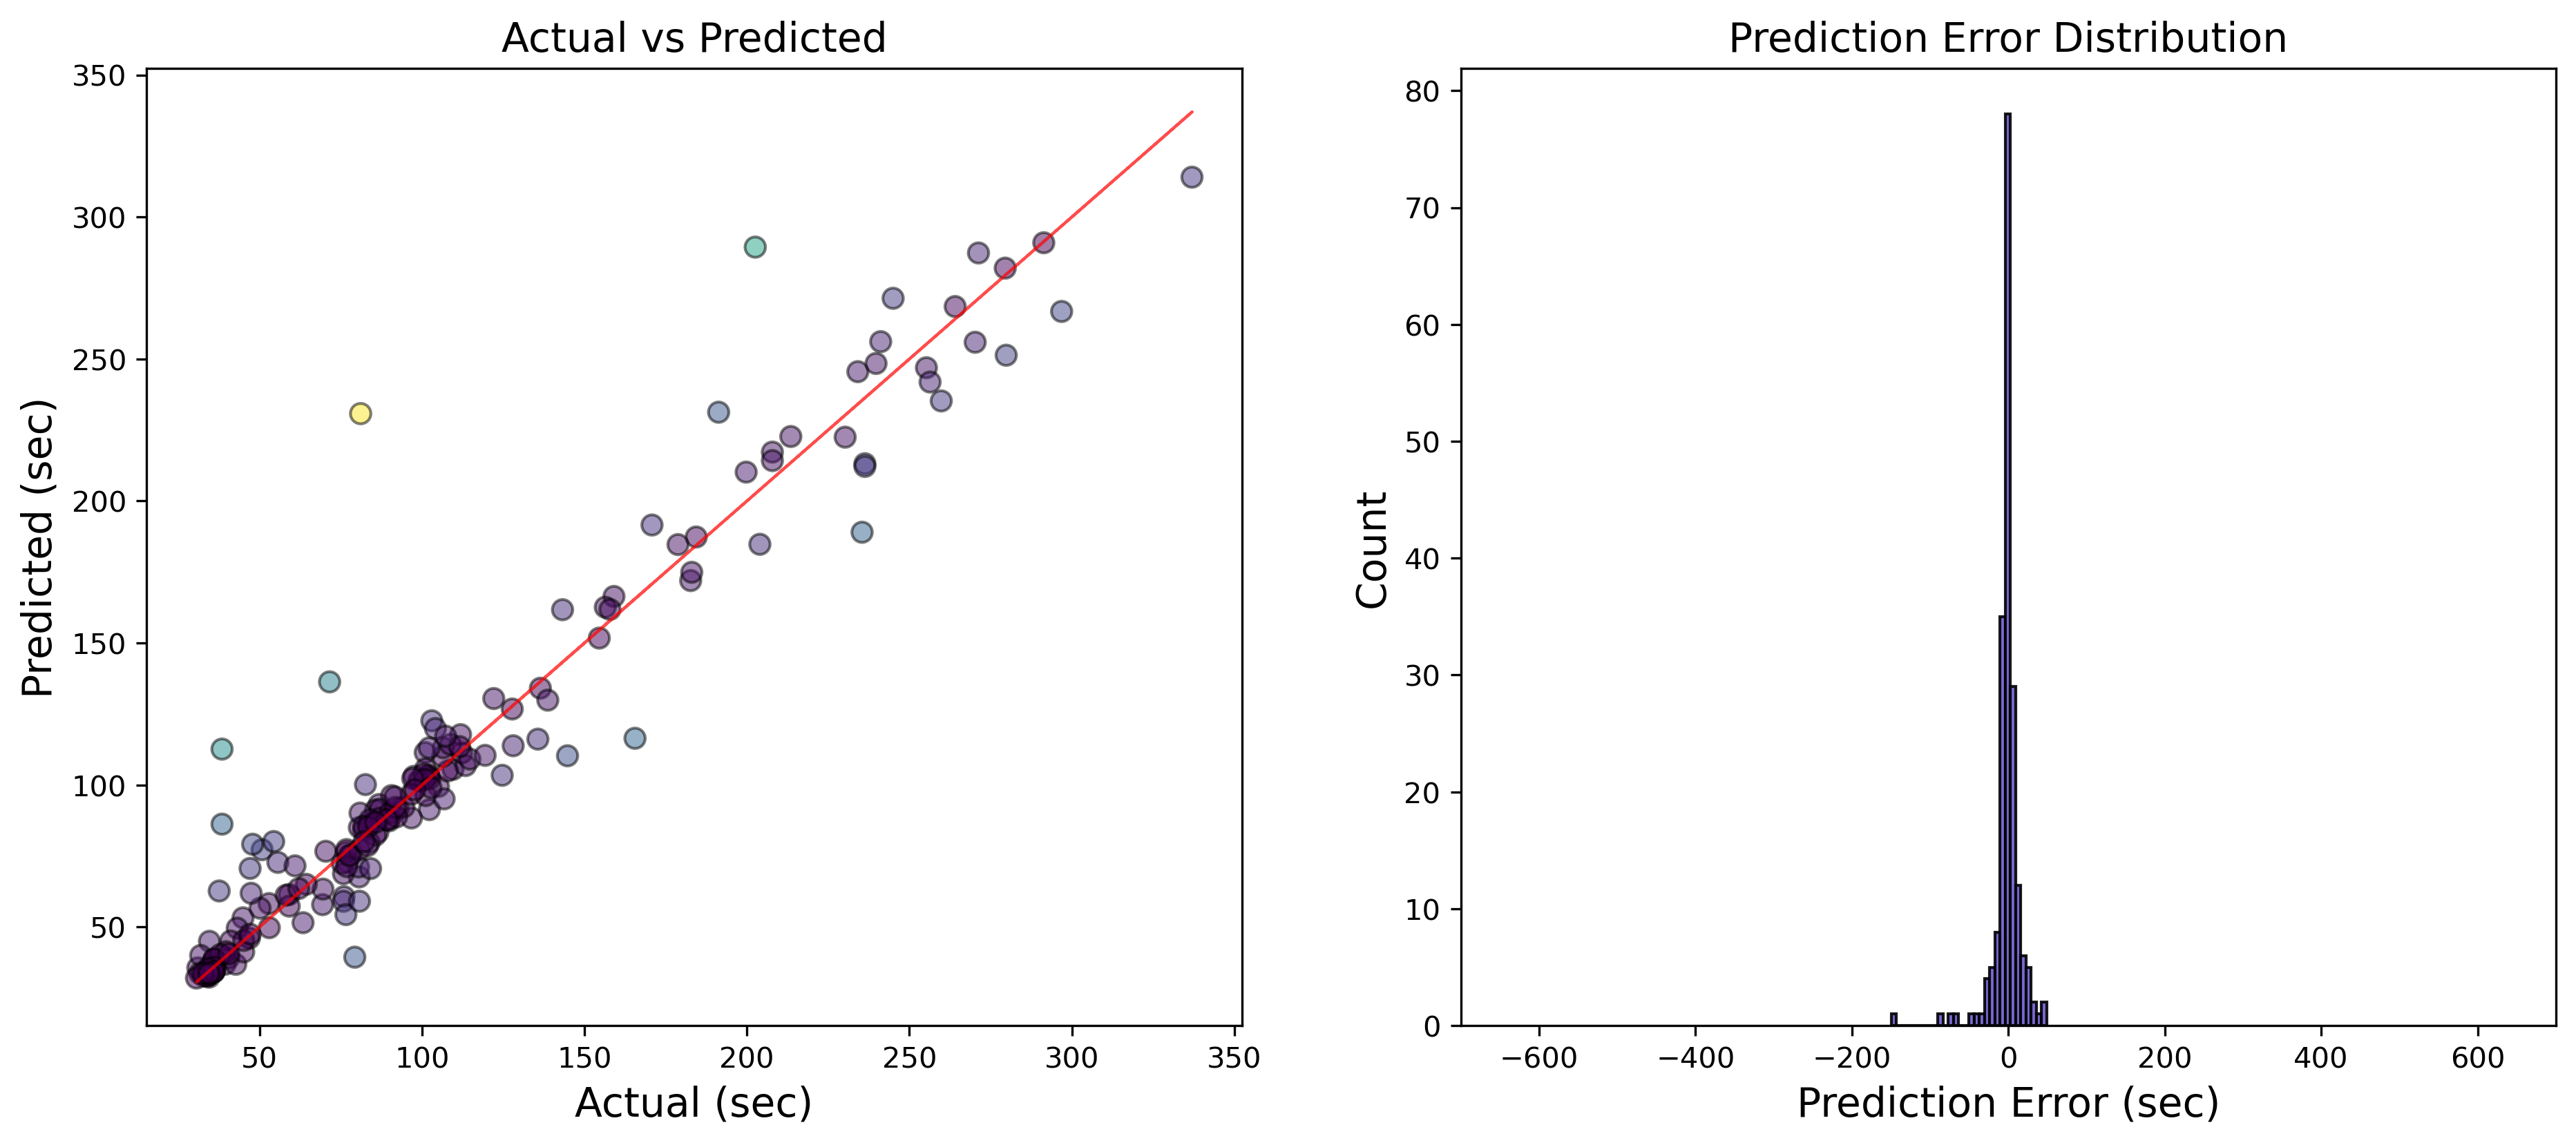

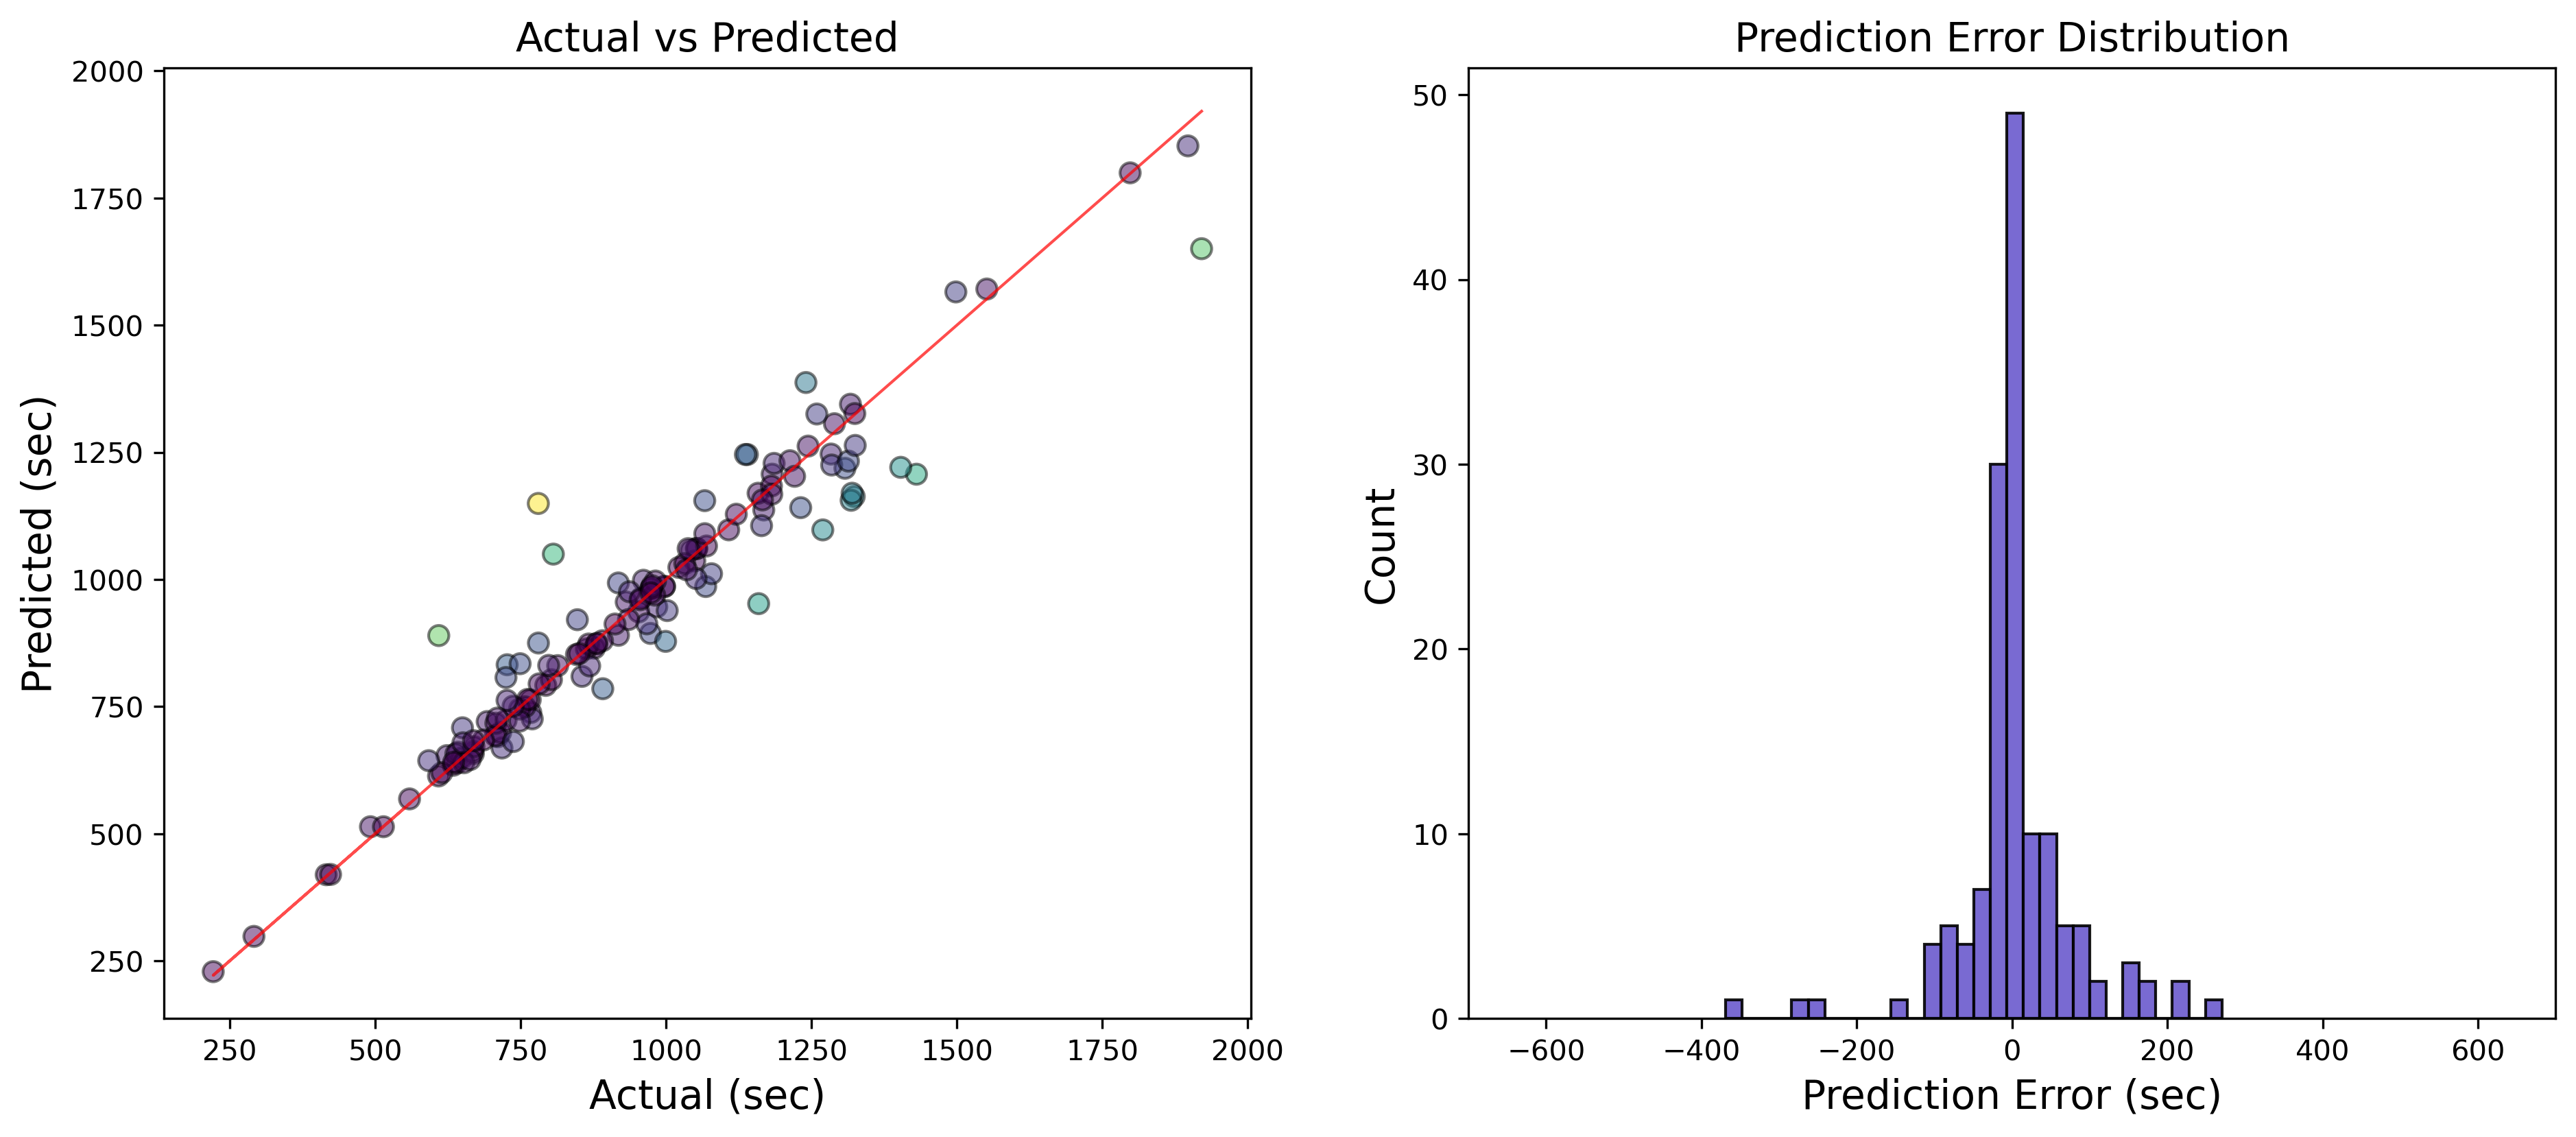

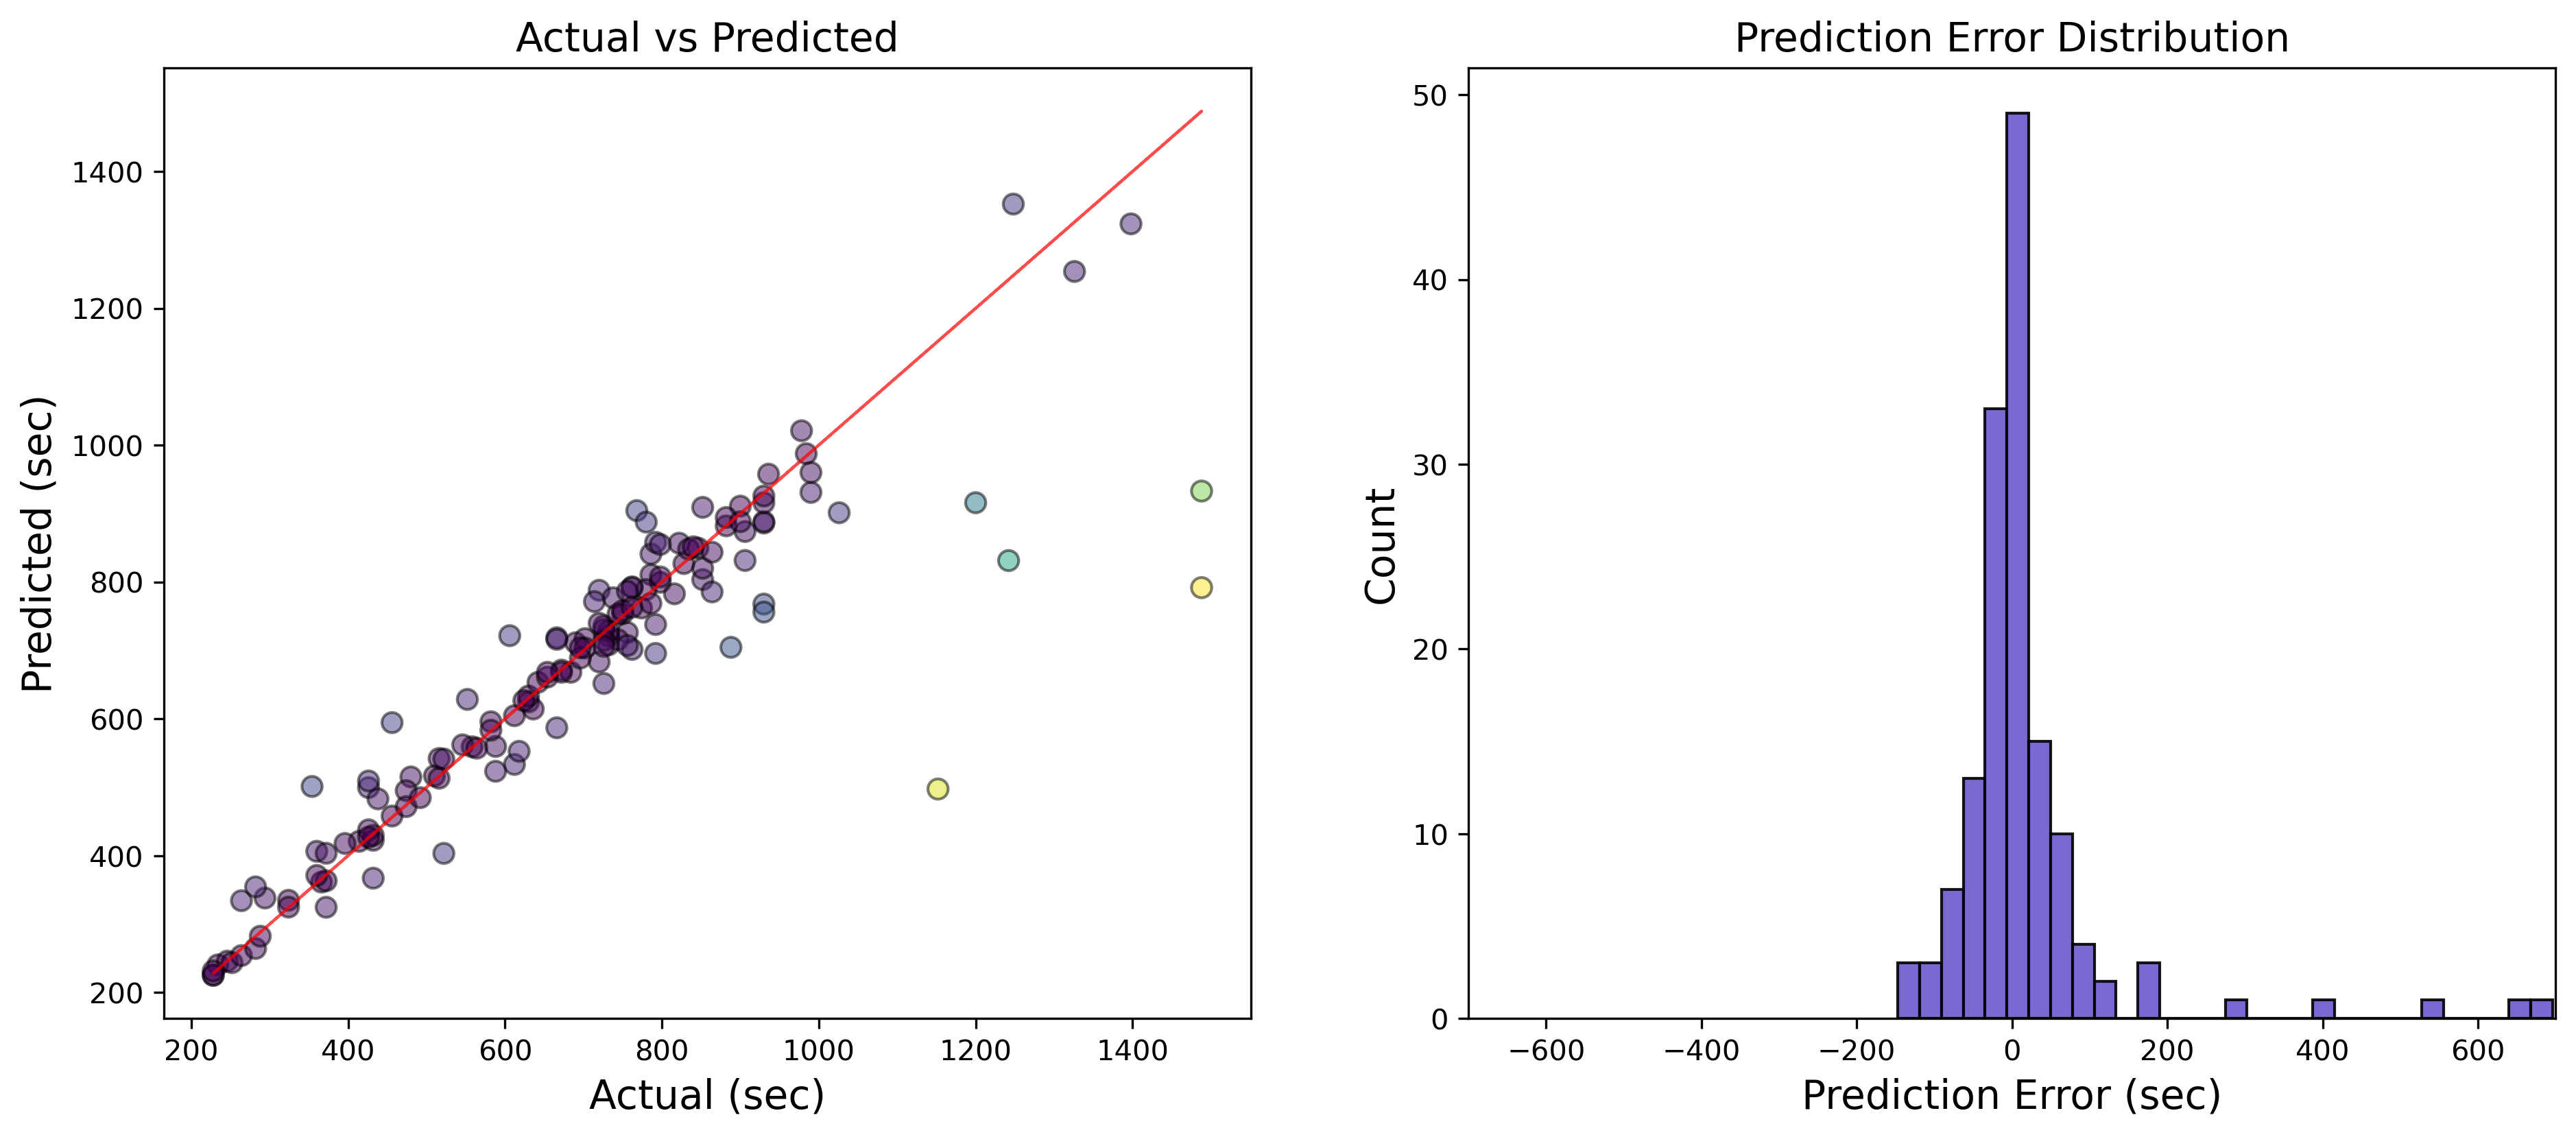

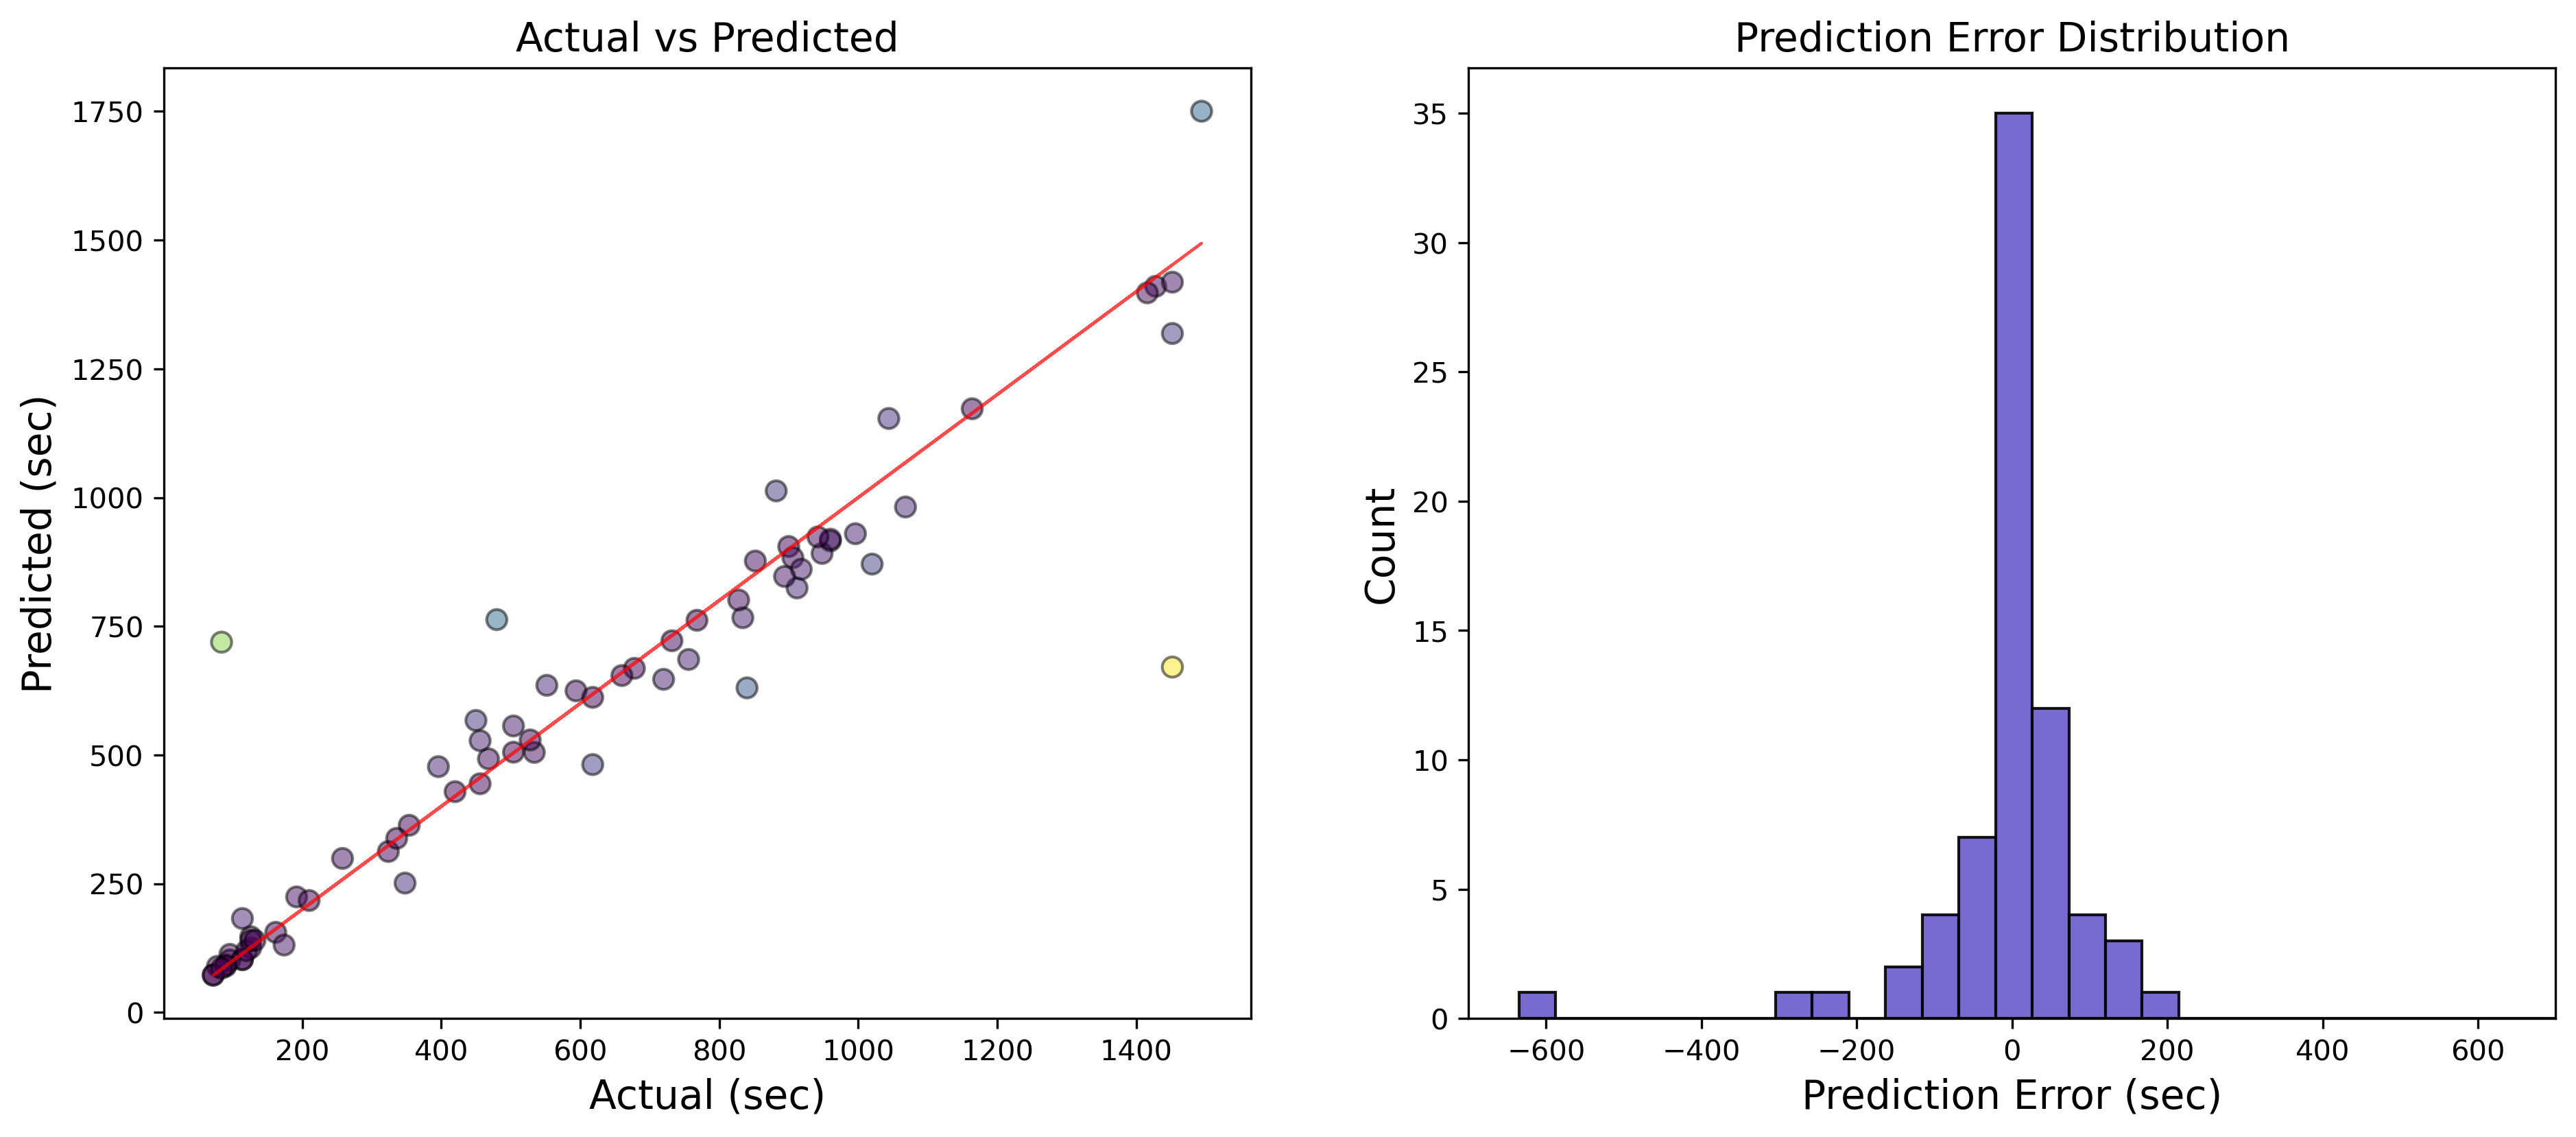

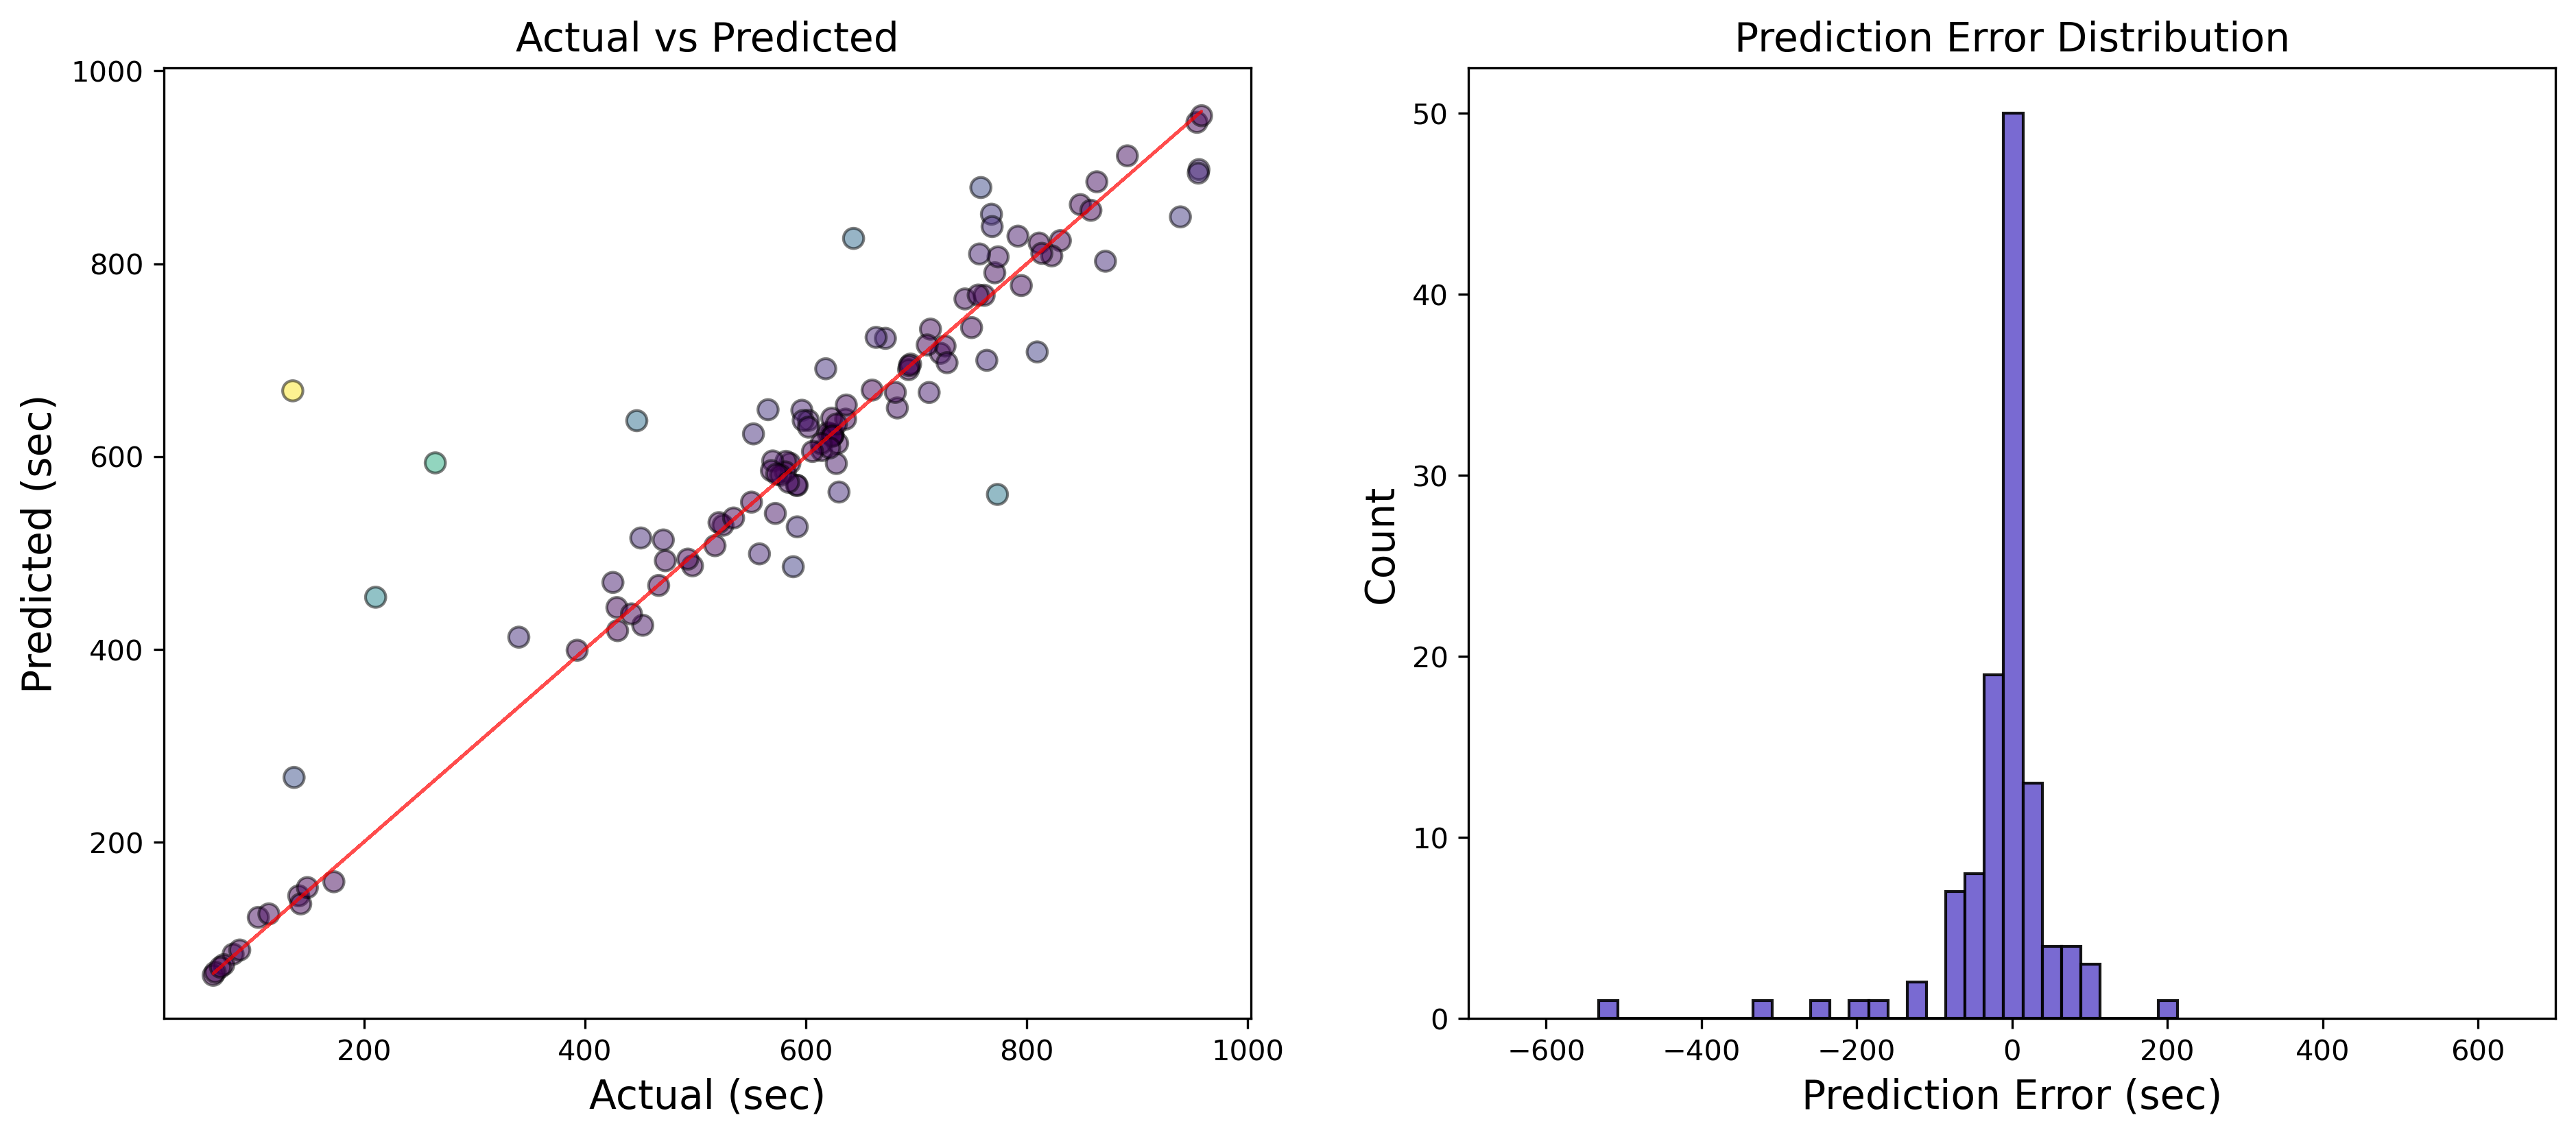

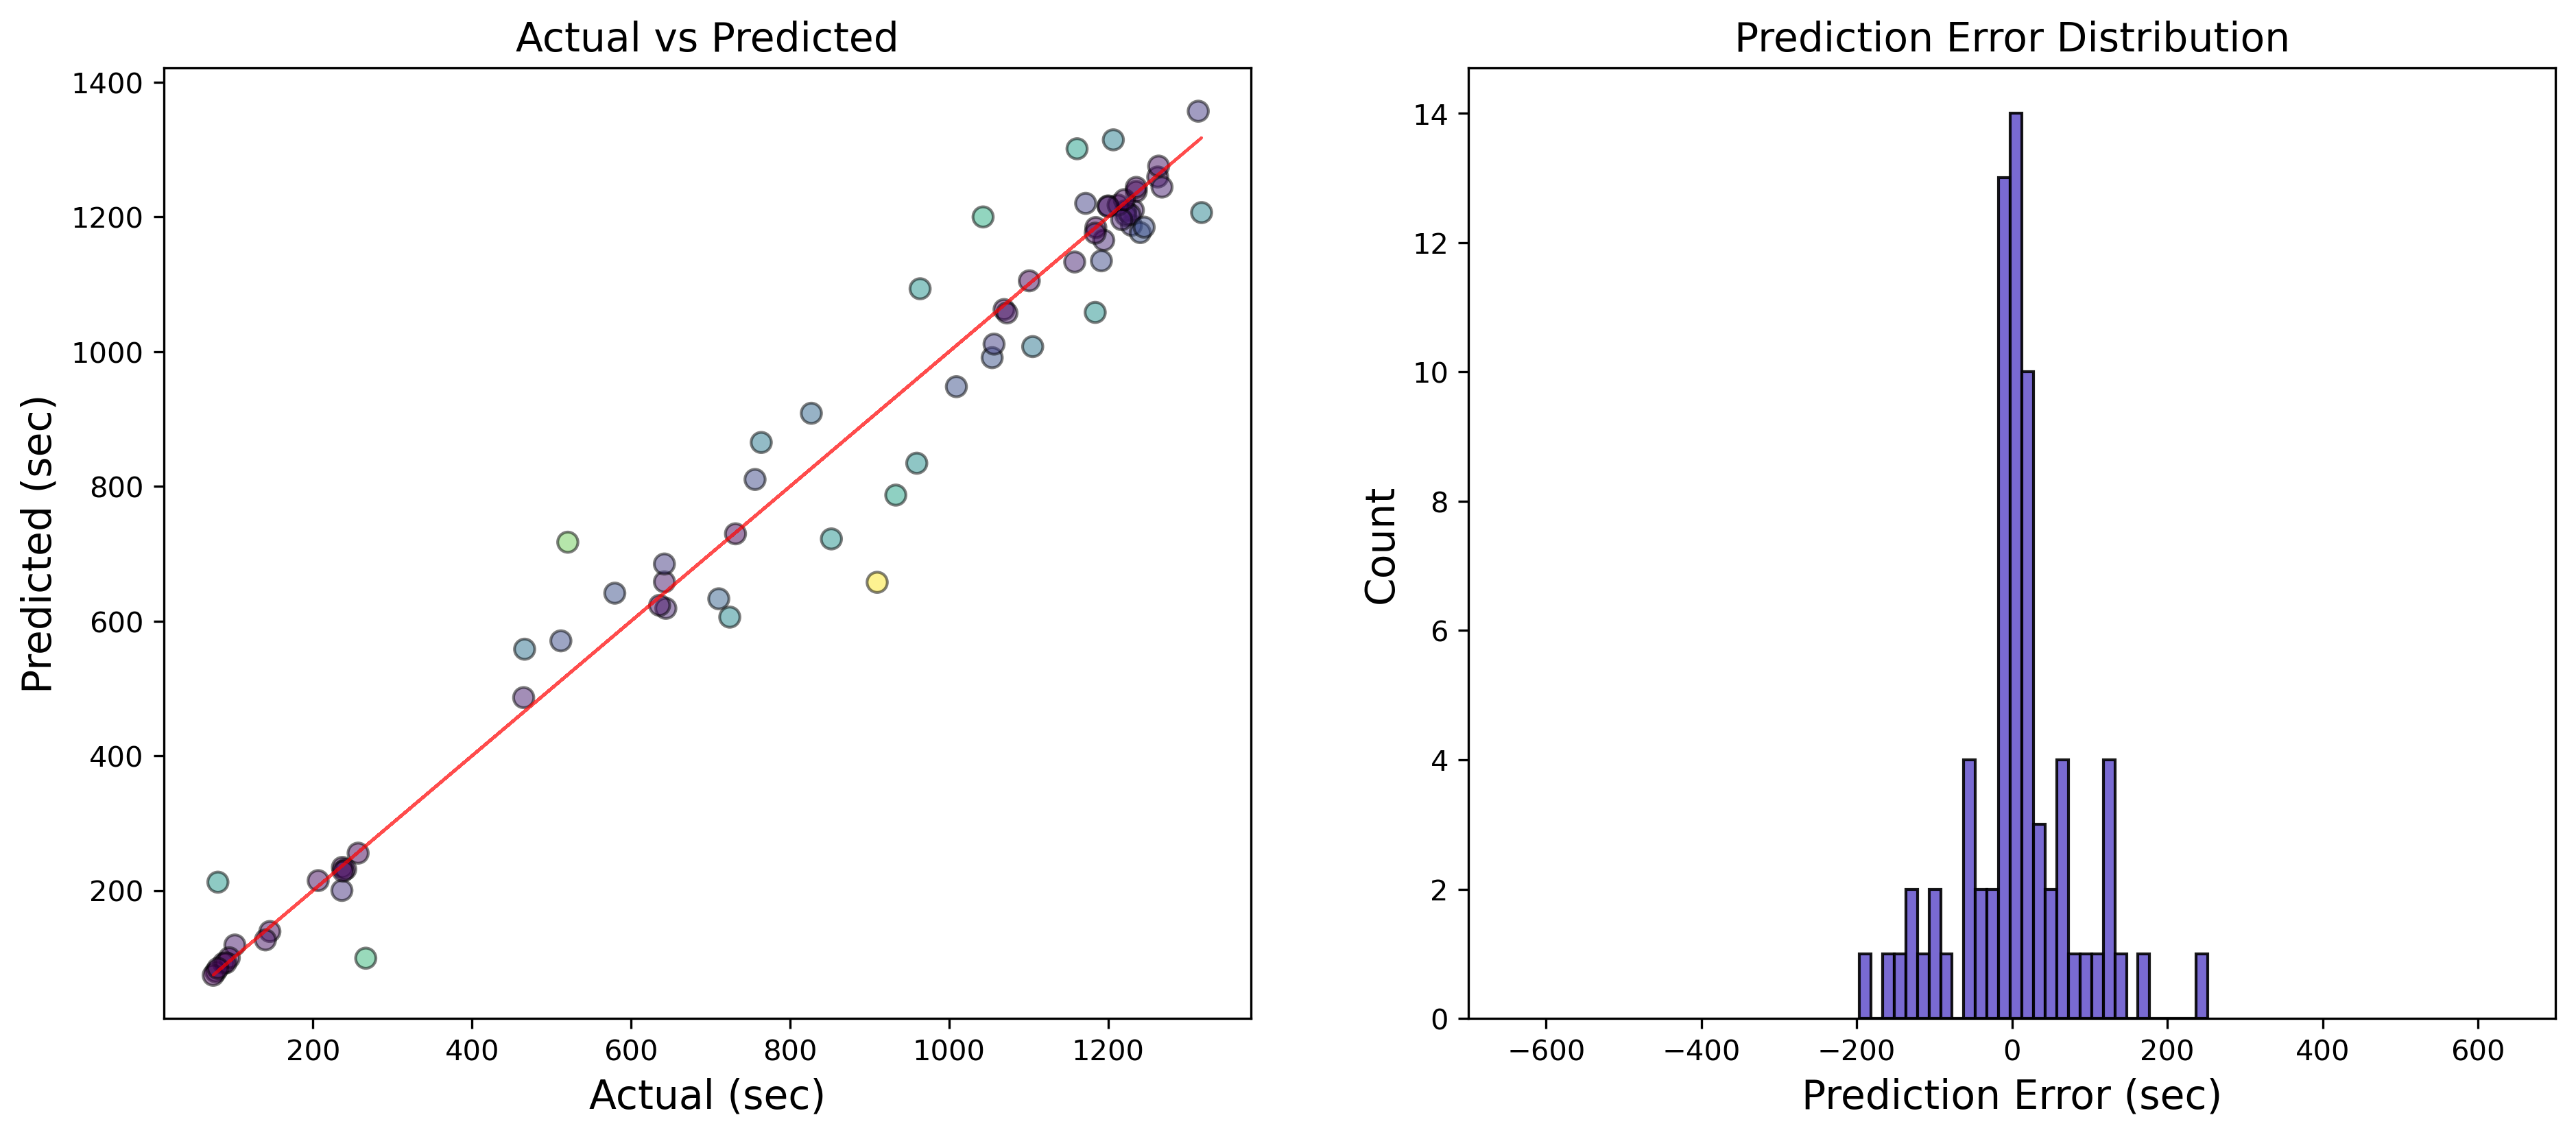

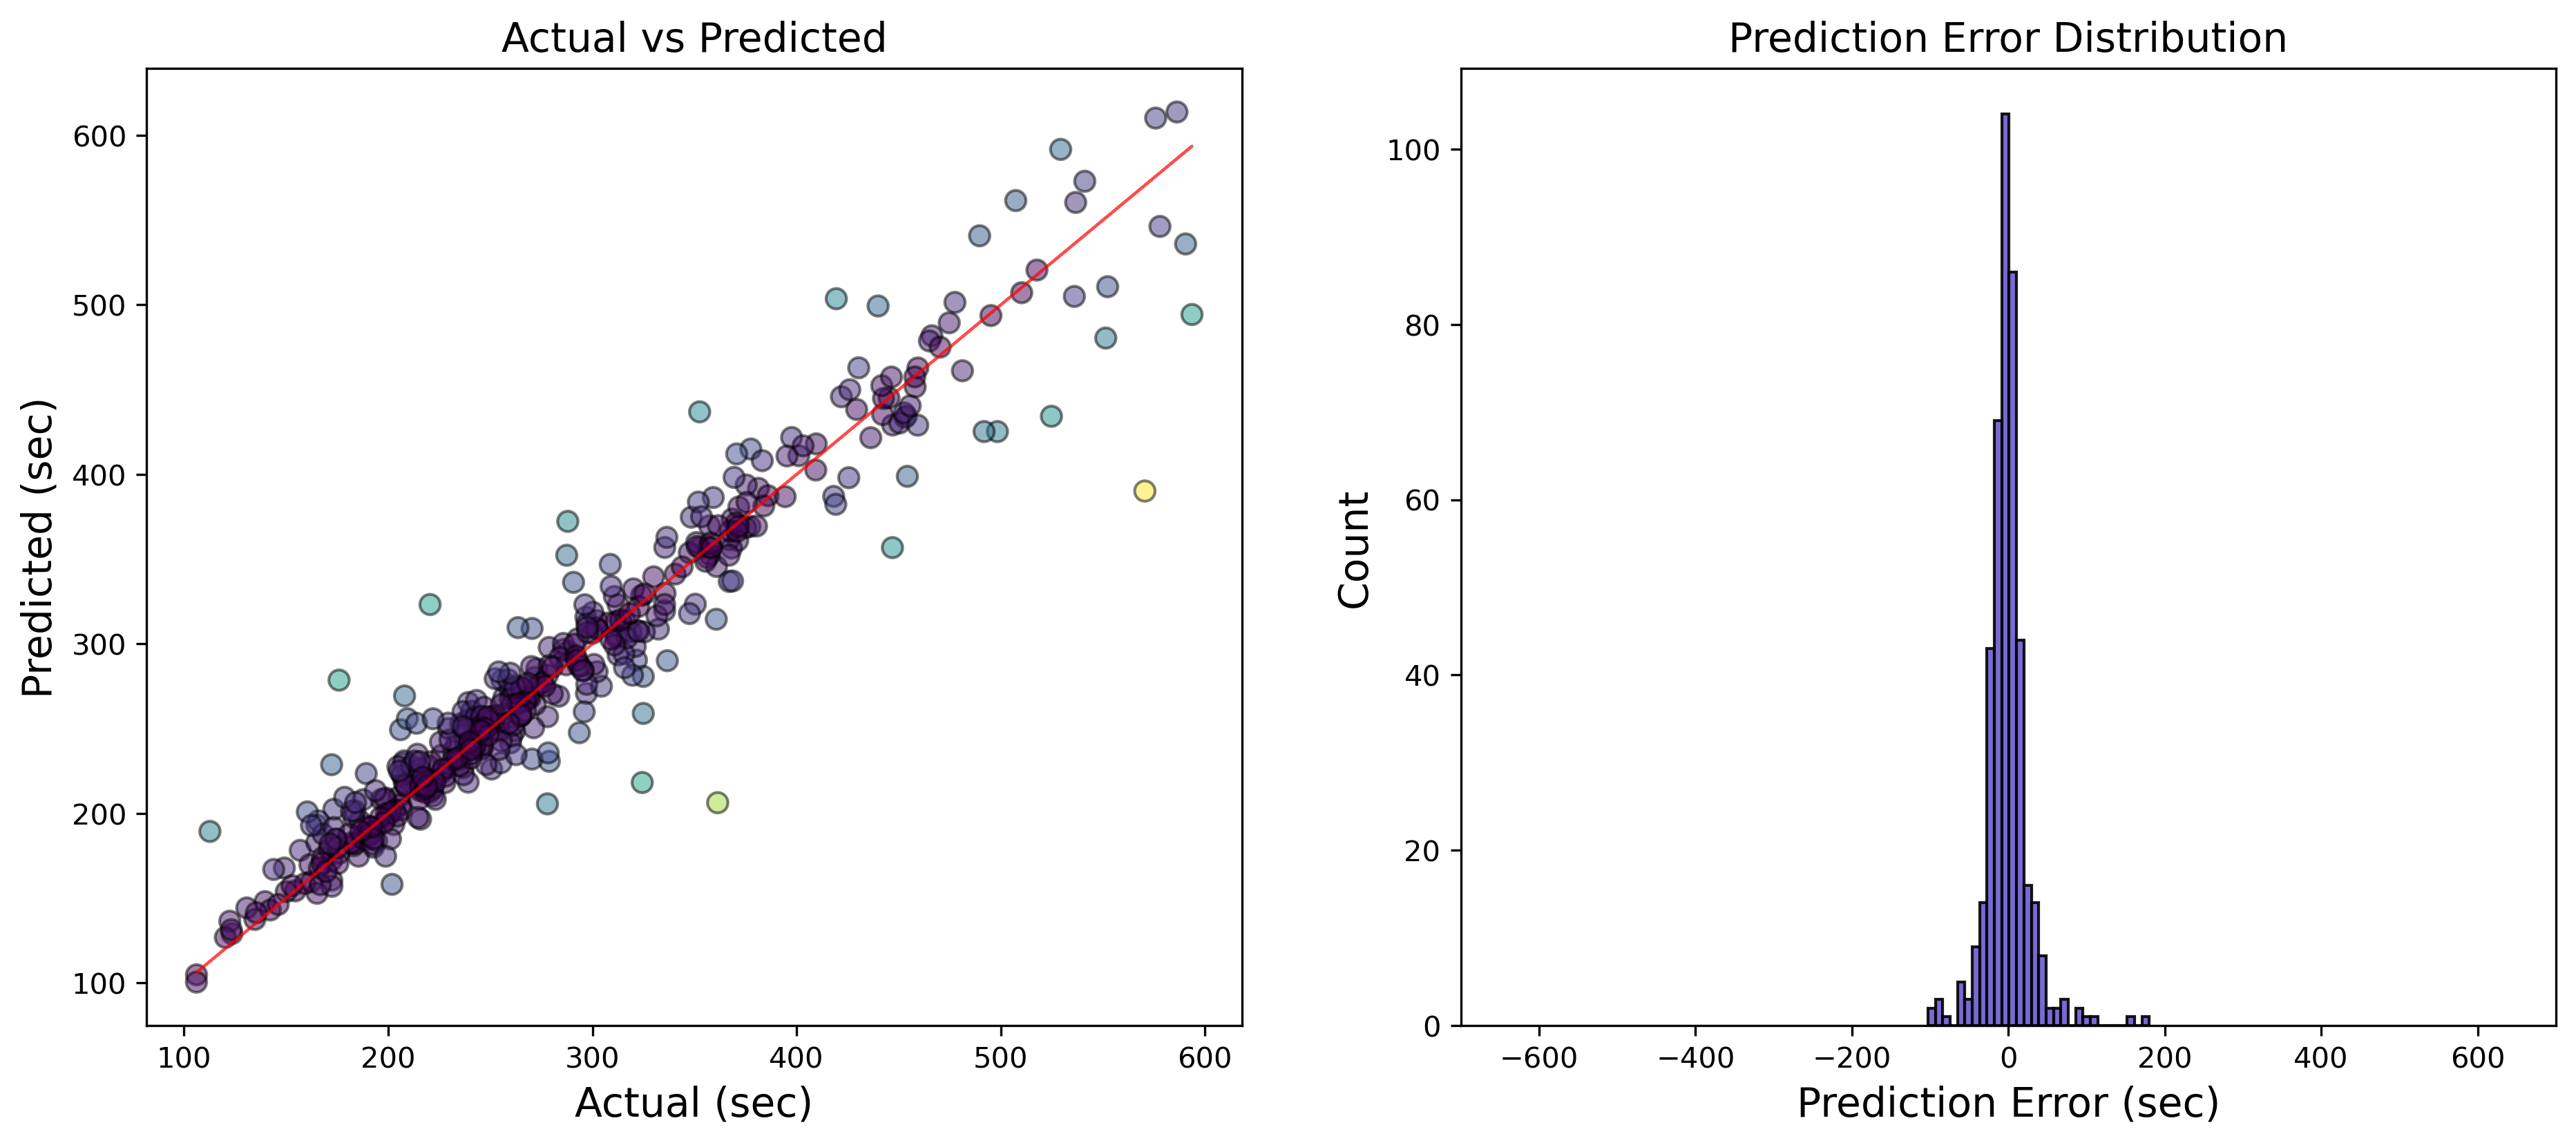

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import numpy as np
from helper import process_predictions


# paths= "/data/home/hadi/test/_runs/2024_09_19/*"

paths = glob.glob("/data/home/hadi/RT-TR/_runs/2024_09_30/*")

for main_path in paths:
    print(main_path)
    csv_pathes = glob.glob(f"{main_path}/*/*/results_*.csv")
    # merge all csv files
    result = pd.concat([pd.read_csv(f) for f in csv_pathes], ignore_index=True)

    # Calculate the distance of each point from the diagonal line
    distances = np.abs(result["rt"] - result["prediction"])

    # Create a colormap based on the distances
    cmap = plt.cm.get_cmap("viridis")
    colors = cmap(distances / distances.max())

    # plot
    fig, axs = plt.subplots(
        1,
        2,
        dpi=300,
        figsize=(15, 6),
    )

    # Scatter plot of actual vs predicted
    axs[0].plot(result["rt"].values, result["rt"].values, color="red", lw=1, alpha=0.7)
    axs[0].scatter(result["rt"], result["prediction"], alpha=0.5, c=colors, edgecolors="k", s=50)
    axs[0].set_xlabel("Actual (sec)", fontsize=14)
    axs[0].set_ylabel("Predicted (sec)", fontsize=14)
    axs[0].set_title("Actual vs Predicted", fontsize=14)

    # Error distribution plot
    error = result["rt"] - result["prediction"]
    axs[1].hist(error, bins=30, edgecolor="black", color="slateblue", alpha=0.9)
    axs[1].set_xlabel("Prediction Error (sec)", fontsize=14)
    axs[1].set_ylabel("Count", fontsize=14)
    axs[1].set_title("Prediction Error Distribution", fontsize=14)
    axs[1].set_xlim(-700, 700)

    plt.savefig(f"{main_path}/RT_prediction.png", dpi=300)
